

<font face="Times New Roman" size=5>
<div dir=rtl align="center">

<br>
<img src="https://logoyar.com/content/wp-content/uploads/2021/04/sharif-university-logo.png" alt="University Logo" width="150" height="150">
<br>
<font face="Times New Roman" size=4 align=center>
Sharif University of Technology - Department of Electrical Engineering
</font>
<br>
<font color="#008080" size=6>
Introduction to Machine Learning
</font>

<hr/>
<font color="#80a080" size=5>
Course Project — Phase 2  
<br>
</font>
<font size=5>
Instructor: Dr. S. Amini
<br>
</font>
<font size=4>
Spring 2025
<br>
</font>
<hr>
</div></font>

> **Student Name**:  Amirali Jafari - Erfan Bateni
> **Student ID**: 400100938 - 400100792

<p style="color:yellow;">Before starting the code, please read the instructions and guidelines provided in "IML_Project_Phase2.pdf". Good luck!.</p>

# **Section1:** Bayesian Linear Regression



## Predicting Student Performance Using MCMC

In this notebook, we look at predicting student outcomes from a set of demographic and character indicators formulating the problem as a supervised regression task. In this part, you will implement Bayesian linear regression using PyMC to estimate students’ final grades. You will also compare the Bayesian approach with several traditional regression models from scikit-learn to assess their predictive performance. Student grades are influenced by many factors, and using a linear model allows us to determine the relationships between these variables and the final performance. Moreover, Bayesian Linear Regression has several advantages over traditional machine learning methods as we will examine.

### **Problem Statement**

This is a supervised regression problem: we have known labels, the final performance of students, that we wish to predict from a set of known features. The labels are continuous (from 1-20) which makes this a regression problem. As a machine learning task, the problem is broken up into two sections: we train the model on a training set of data and then make preditions on a hold-out testing set. There are numerous common machine learning approaches for supervised regression, most of which can be quickly built, trained, and evaluated in `scikit-learn`. We will compare the Bayesian Linear Regression method to several other machine learning approaches.

### Dataset

The data about student performance was collected from a Portuguese secondary school and is available at the [UCI machine learning repository](http://archive.ics.uci.edu/ml/datasets/Student+Performance). The target variable to predict is `G3`, the final student grade ranging from 1 to 20. There are 30 features (explanatory variables) in the original data, but in order to reduce dimensionality we retain only the most highly correlated features with the response. To carry out feature reduction, we calculate the Pearson Correlation Coefficient between all the features and the response and retain only the features with a absolute magnitude of the correlation coefficient greater than 0.2. Given that we are performing linear regression, selecting variables that are highly linearly correlated with the response should improve the performance of the model by removing noise from irrelevant features.

***Features (Explanatory Variables):*** The final set of five features selected using the cut-off of 0.2 for the absolute magnitude of the correlation coefficient with the response are:

1. `failures`: number of previous class failures, numeric, the feature represents the number of classes if $1 <= n <3$ else the value is 4.
2. `higher_yes`: binary, 0 if the student does not want to pursue higher education and 1 if the student does want to pursue higher education.
3. `Medu`: Mother's education, numeric, 0 = none, 1 = primary education (4th grade), 2 = 5th to 9th grade, 3 = secondary education, 4 = higher education
4. `studytime`: time of studying per week, numeric, 1: <2 hours, 2: 2 to 5 hours, 3: 5 to 10 hours, 4: >10 hours
5. `Dalc`: daily alcohol consumption during the week, numeric, 1 very low to 5 very high

## **Bayesian Linear Regression**

The standard linear regression model is

$$ Y = X\beta + \epsilon $$

Where Y is the target, X is the predictor matrix, $\beta$ is the weights vector, and $\epsilon$ is an error term (assumed to be normally distributed). The weights are found using ordinary least squares to minimum the residual sum of squares between the observations (training data) and the fitted model.

In a Bayesian framework, Linear Regression takes the form

$$ Y \sim \mathcal{N}(X \beta, \sigma^2) $$

Where Y is a random variable with each data point distributed according to a normal distribution. The mean of the normal distribution comes from the data points multiplied by the weights vector $\beta$ with a variance of $\sigma^2$.

The Bayesian Linear Regression framework has two main advantages:

* Priors: Any previous knowledge about the problem can be quantified by placing prior probabilities on the model parameters. For example, we can assume that the model parameters come from Normal Distributions centered at different values. We can use other distributions such as the Student T-Distribution for the priors of the parameters as well. If we have knowledge about the values of the parameters, we could use these as starting values for the sampling.
* Uncertainty: Bayesian inference using Markov Chain Monte Carlo does not yield a single estimate for each weight, but rather a posterior _distribution_ from which we can draw conclusions about how likely different values of the weights $\beta$ are in our model. With fewer data points, there will be more uncertainty in $\beta$ and the posterior distributions will be very wide. When we need to make predictions from the model, we can use the entire range of samples to calculate a range of estimates rather than a single value. We can then specify a confidence interval for our estimate in addition to a most likely single value.

We will compare the results of Bayesian Linear Regression with several traditional machine learning models.

### Data Formatting

We want to reduce the number of features to speed up the algorithm and remove potentially non-informative features. As we are creating a linear model, a decent approach is to retain the most highly linearly correlated features with the response variable.

In [ ]:
# Data manipulation and analysis
import pandas as pd
import numpy as np
np.random.seed(42)  # Ensures reproducible results

# Statistical computations
from scipy import stats

# Visualization
import matplotlib.pyplot as plt
%matplotlib inline
import seaborn as sns
import matplotlib
matplotlib.rcParams['font.size'] = 16  # Larger font size for readability

# Train-test split and normalization
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import MinMaxScaler

# Ensures larger plot sizes for better visibility in Jupyter notebooks
from IPython.core.pylabtools import figsize


### Step 1: Load and Explore the Dataset

We use a dataset on Portuguese secondary school students. The target variable `G3` represents the final grade (ranging from 1 to 20). To simplify the model and improve interpretability, we will perform feature selection based on linear correlation with the target.


In [ ]:
!pip install ucimlrepo

In [ ]:

from ucimlrepo import fetch_ucirepo

# Fetch the dataset
student_performance = fetch_ucirepo(id=320)

# Combine features and targets into a single DataFrame
math = pd.concat([
    student_performance.data.features,
    student_performance.data.targets
], axis=1)

# Remove rows where final grade (G3) is zero — likely due to missing/incomplete records
math = math[math['G3'] != 0]

# Preview the dataset
math.head()


,school,sex,age,address,famsize,Pstatus,Medu,Fedu,Mjob,Fjob,...,famrel,freetime,goout,Dalc,Walc,health,absences,G1,G2,G3
0,GP,F,18,U,GT3,A,4,4,at_home,teacher,...,4,3,4,1,1,3,4,0,11,11
1,GP,F,17,U,GT3,T,1,1,at_home,other,...,5,3,3,1,1,3,2,9,11,11
2,GP,F,15,U,LE3,T,1,1,at_home,other,...,4,3,2,2,3,3,6,12,13,12
3,GP,F,15,U,GT3,T,4,2,health,services,...,3,2,2,1,1,5,0,14,14,14
4,GP,F,16,U,GT3,T,3,3,other,other,...,4,3,2,1,2,5,0,11,13,13


The continuous variable (which makes this a regression problem) that we want to predict is the final student grade in the course. This is in the `G3` column. The `G1` and `G2` columns are the first semester and second semester grades respectively. The target variable for this regression task is `G3`, the final student grade. The dataset also contains `G1` and `G2` — grades from the first and second periods of the course. Since these are highly predictive of the final grade (and could be considered “leakage” features), we remove them from the feature set to better model the influence of other explanatory variables.

In [ ]:
# Summary statistics for the final grade (target variable)
math['G3'].describe()

,G3
count,634.000000
mean,12.187697
std,2.691824
min,1.000000
25%,10.000000
50%,12.000000
75%,14.000000
max,19.000000


Let's take a look at the distribution of final grades. We have already dropped any grades that are 0.

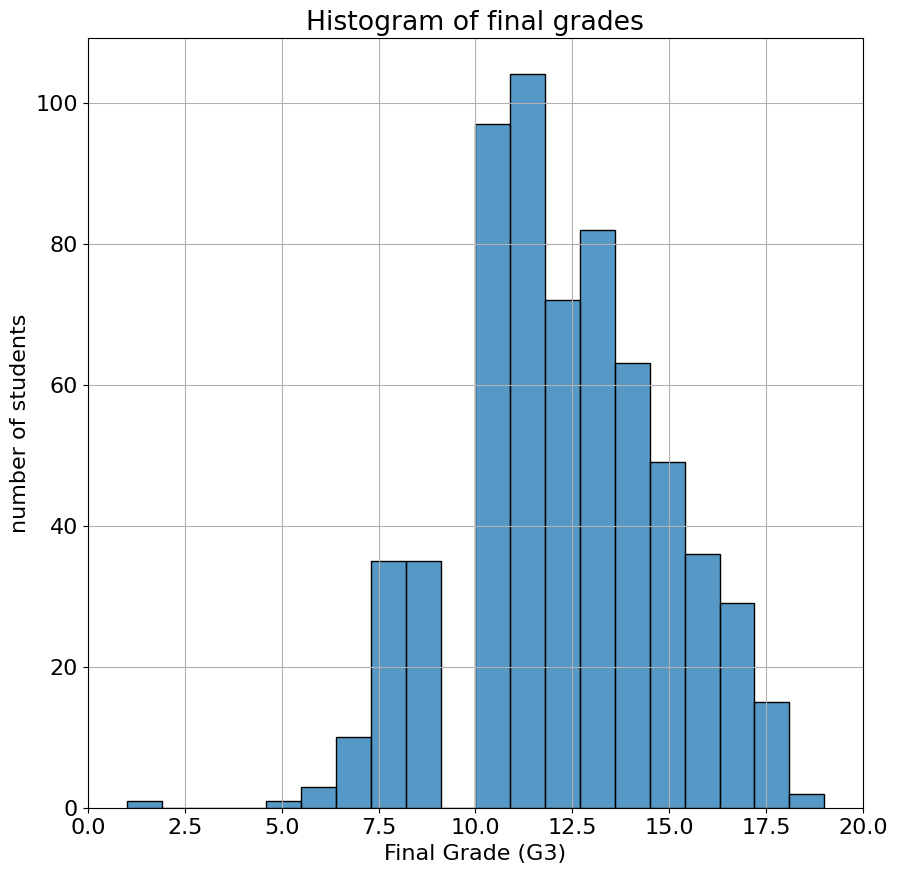

In [ ]:
# TODO: Create a histogram of final grades (G3)
# Your code here
plt.figure(figsize=(10, 10))
sns.histplot(math['G3'], bins=20, kde=False)
plt.title('Histogram of final grades')
plt.xlabel('Final Grade (G3)')
plt.ylabel('number of students')
plt.xlim(0, 20)
plt.grid()
plt.show()

### Data Preparation

Now we prepare the dataset for modeling. This includes:

1. One-hot encoding categorical variables.
2. Calculating correlation of features with the target.
3. Choosing only those variables with an absolute magnitude of the correlation coefficient greater than 0.2.
4. Splitting the dataset into training and testing sets (75/25).

In [ ]:
# TODO: Prepare the dataset for modeling by completing the following steps:
# 1. Extract the target variable ('G3') as labels
# 2. Drop columns that shouldn't be used as features:
#    - 'school' (identifier) ,'G1', 'G2' (previous grades), 'G3' (target variable)
# 3. Perform one-hot encoding on all categorical variables
# 4. Add the labels back to the dataframe as column 'y'
# 5. Calculate feature correlations with the target and:
#    - Sort by absolute correlation values (descending)
#    - Keep only features with correlation >= 0.2 (excluding target itself)
# 6. Drop redundant one-hot encoded column 'higher_no' (keep 'higher_yes')

def format_data(df):
    # Your code here
    # Step 1: Extract target
    labels = df['G3']

    # Step 2: Drop columns
    df = df.drop(columns=['school', 'G1', 'G2', 'G3'])

    # Step 3: One-hot encode categorical variables
    df = pd.get_dummies(df, drop_first=True)

    # Step 4: Add labels back as a new column 'y' for correlation
    df['y'] = labels

    # Step 5: Correlation filtering
    correlation = df.corr(numeric_only=True)['y'].drop('y')
    selected_features = correlation[abs(correlation) >= 0.2].index.tolist()
    df = df[selected_features]

    # Step 6: Drop redundant one-hot encoded column if both present
    if 'higher_no' in df.columns:
        df = df.drop(columns=['higher_no'])

    # Train-test split
    X_train, X_test, y_train, y_test = train_test_split(
        df, labels, test_size=0.25, random_state=42
    )

    # Return results
    return X_train, X_test, y_train, y_test

In [ ]:
# Format the data using the defined function
X_train_math, X_test_math, y_train_math, y_test_math = format_data(math)
# Convert 'higher_yes' from boolean to integer (0/1) for modeling
X_train_math['higher_yes'] = X_train_math['higher_yes'].astype(int)
X_test_math['higher_yes'] = X_test_math['higher_yes'].astype(int)
# Preview the training data
X_train_math.head()


,Medu,studytime,failures,Dalc,higher_yes
619,3,2,0,1,1
596,4,2,0,1,1
550,2,2,0,2,1
516,4,2,0,2,1
472,2,1,0,1,1


After preprocessing, we are left with five variables most correlated with student final grades. These serve as our predictors in the subsequent modeling phase. This dimensionality reduction helps improve generalization and interpretability.

### Pairplot of Final Variables

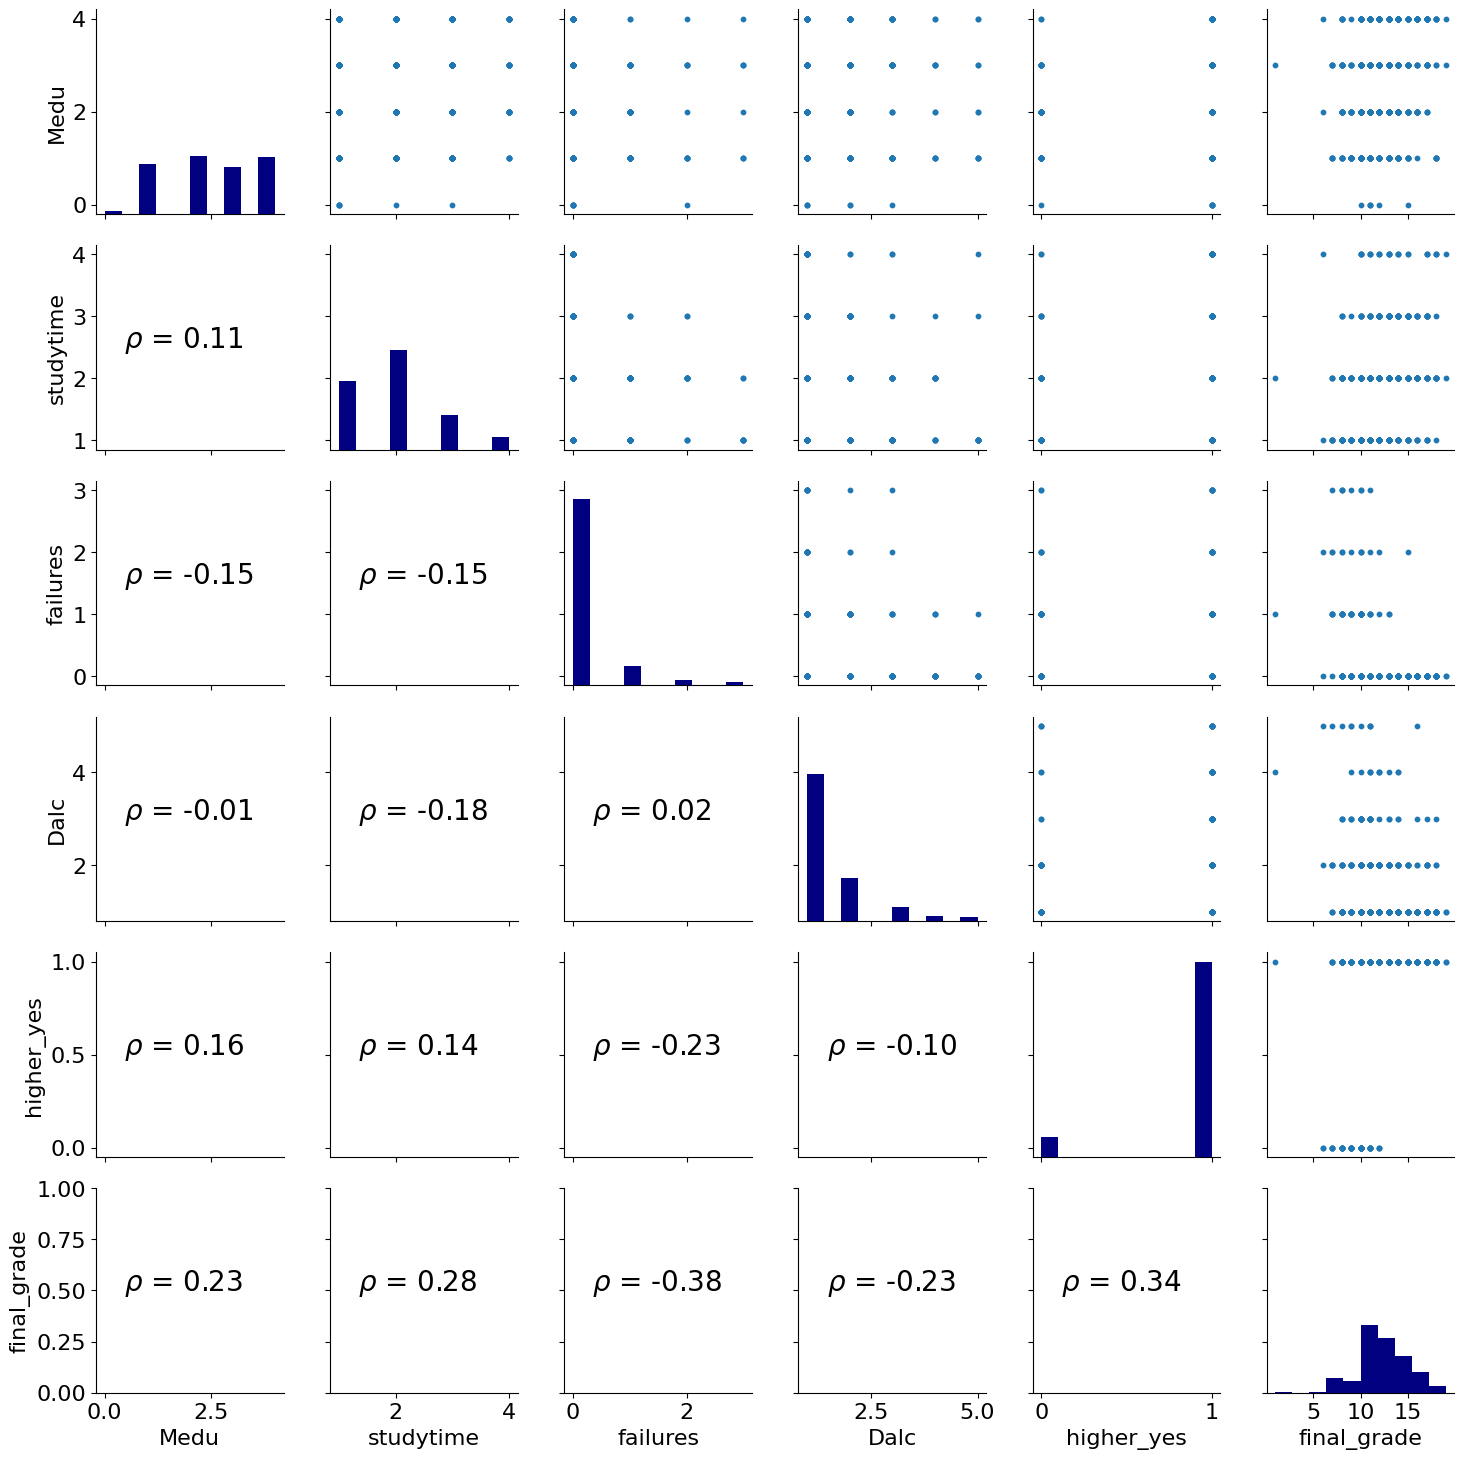

In [ ]:
X_train_labels = X_train_math.copy()
X_train_labels['final_grade'] = list(y_train_math)

# Calculate correlation coefficient
def corrfunc(x, y, **kws):
    r, _ = stats.pearsonr(x, y)
    ax = plt.gca()
    ax.annotate(r"$\rho$ = {:.2f}".format(r),
                xy=(.15, .5), xycoords=ax.transAxes,
               size = 20)

# Pair grid set up
g = sns.PairGrid(X_train_labels, palette=["red"])

# Scatter plot on the upper triangle
g.map_upper(plt.scatter, s=10)

# Distribution on the diagonal
g.map_diag(plt.hist, color = 'navy')

# Correlation coefficients on the lower triangle
g.map_lower(corrfunc);

## Evaluate Common ML Models for a Benchmark

We evaluate a suite of traditional ML regressors to establish baselines:

- Linear Regression
- ElasticNet Regression
- Random Forest
- Extra Trees
- Support Vector Regressor
- Gradient Boosted Trees
- Median value baseline (simple heuristic)

 **Evaluation Metrics:**
- **RMSE**: Penalizes large errors.
- **MAPE**: Reflects average percentage error (100 - MAPE is approximate “accuracy”).

This sets performance baselines for later comparison with the Bayesian Linear Regression.


In [ ]:
# Standard ML Models for comparison
from sklearn.linear_model import LinearRegression, ElasticNet
from sklearn.ensemble import RandomForestRegressor, ExtraTreesRegressor, GradientBoostingRegressor
from sklearn.svm import SVR

# Metrics
from sklearn.metrics import mean_squared_error

In [ ]:
def evaluate(X_train, X_test, y_train, y_test):
    # Names of models
    model_name_list = ['Linear Regression', 'ElasticNet Regression',
                      'Random Forest', 'Extra Trees', 'SVM',
                      'Gradient Boosted', 'Median Baseline']

    # Instantiate the models
    model1 = LinearRegression()
    model2 = ElasticNet(alpha=1.0, l1_ratio=0.5)
    model3 = RandomForestRegressor(n_estimators=500)
    model4 = ExtraTreesRegressor(n_estimators=500)
    model5 = SVR(kernel='rbf', degree=3, C=1.0, gamma='auto')
    model6 = GradientBoostingRegressor(n_estimators=100)

    # Dataframe for results
    results = pd.DataFrame(columns=['rmse', 'mape'], index=model_name_list)

    # TODO: Convert y_test to numpy array to avoid recursion issues
    y_test_np = y_test.to_numpy()
    y_train_np = y_train.to_numpy()
    # Train and predict with each model
    for i, model in enumerate([model1, model2, model3, model4, model5, model6]):
        # TODO: Fit model on training data
        model.fit(X_train, y_train)
        # TODO: Predict on test data
        predictions = model.predict(X_test)
        # Metrics
        # TODO: Compute MSE and RMSE
        mse = mean_squared_error(y_test_np, predictions)
        rmse = np.sqrt(mse)

        # Calculate MAPE safely
        with np.errstate(divide='ignore', invalid='ignore'):
            mape = 100 * np.mean(np.abs((y_test_np - predictions) / y_test_np))
        mape = np.nan_to_num(mape, nan=0.0, posinf=0.0, neginf=0.0)

        # Insert results into the dataframe
        model_name = model_name_list[i]
        # TODO: Store rmse and mape into the results dataframe
        results.loc[model_name, :] = [rmse, mape]

    # Median Value Baseline Metrics
    baseline_pred = np.median(y_train_np)
    baseline_mse = mean_squared_error(y_test_np, np.full_like(y_test_np, baseline_pred))
    baseline_rmse = np.sqrt(baseline_mse)

    with np.errstate(divide='ignore', invalid='ignore'):
        baseline_mape = 100 * np.mean(np.abs((y_test_np - baseline_pred) / y_test_np))
    baseline_mape = np.nan_to_num(baseline_mape, nan=0.0, posinf=0.0, neginf=0.0)

    results.loc['Median Baseline', :] = [baseline_rmse, baseline_mape]

    return results

#### Illustrating the Results

In [ ]:
math_results = evaluate(X_train_math, X_test_math, y_train_math, y_test_math)

Text(0, 0.5, 'MAPE (%)')

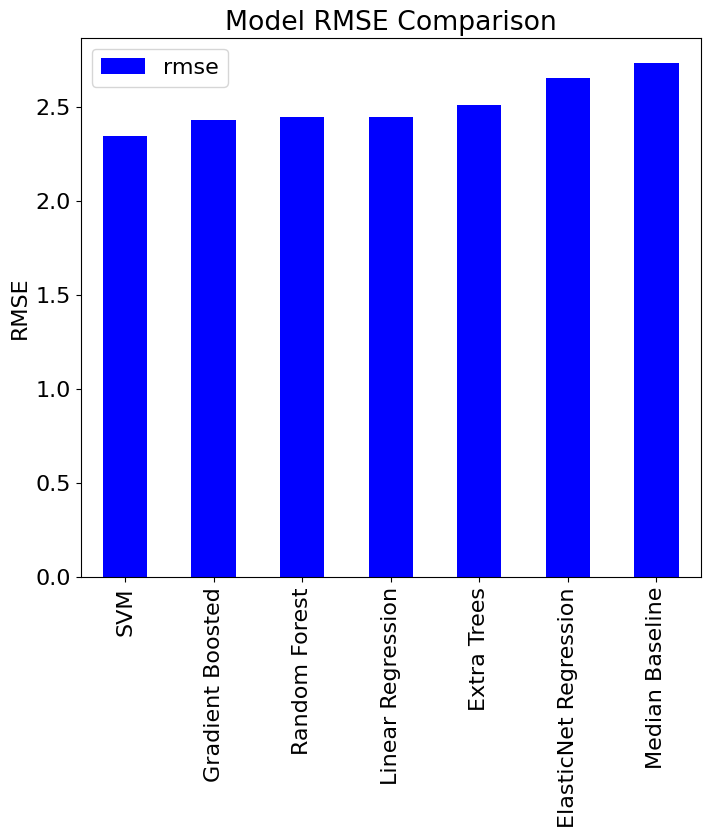

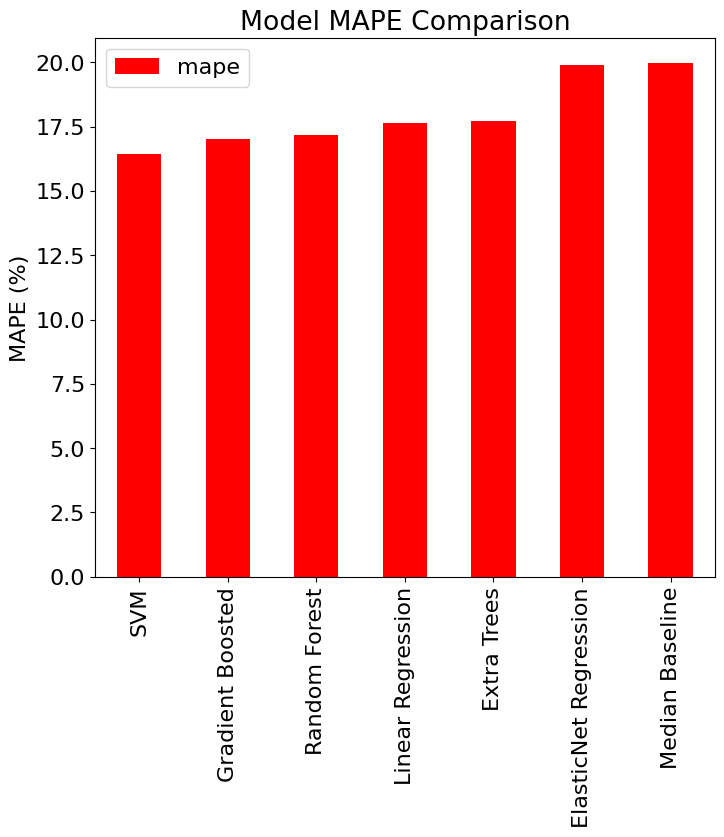

In [ ]:
figsize(8, 7)

# RMSE Comparison
math_results.sort_values('rmse', ascending=True).plot.bar(y='rmse', color='b')
plt.title('Model RMSE Comparison'); plt.ylabel('RMSE')

# MAPE Comparison
math_results.sort_values('mape', ascending=True).plot.bar(y='mape', color='r')
plt.title('Model MAPE Comparison'); plt.ylabel('MAPE (%)')


**Question:** Which model performs best according to the evaluation metrics, and how do all models compare to the baseline?

**Answer:** <span style="color:red">**Based on the evaluation using RMSE** and **MAPE**, the **Support Vector Machine (SVM)** model demonstrates the best performance. It achieves the lowest RMSE (smallest average prediction error) as well as the lowest MAPE (lowest average percentage error), making it the most accurate model among those tested.

Other models, such as **Gradient Boosted Trees** and **Random Forest**, also show strong performance, with only slightly higher errors. All models significantly outperform the **Median Baseline**, indicating that the features used carry substantial predictive value.
**</span>

 **Note:** No hyperparameter tuning was applied. These benchmarks can be improved via cross-validation.


## Standard Linear Regression Outcome

In [ ]:
# Fit a linear regression on the training data
# TODO: Instantiate a LinearRegression model and fit it on X_train_math and y_train_math
LinearRegression = LinearRegression()
LinearRegression.fit(X_train_math, y_train_math)
# Model parameters
# TODO: Get the intercept and coefficients of the trained model
intercept = LinearRegression.intercept_
coefs = LinearRegression.coef_
# Write the final equation
final_equation = 'grade = %0.2f + ' % intercept

for var, weight in zip(X_train_math.columns, coefs):
    final_equation += '%0.2f * %s + ' % (weight, var)

final_equation = ' '.join(final_equation.split(' ')[:-2])

# Display the equation
print('Final Equation from Standard (OLS) Linear Regression:\n')
print(final_equation)

Final Equation from Standard (OLS) Linear Regression:

grade = 9.64 + 0.33 * Medu + 0.52 * studytime + -1.38 * failures + -0.52 * Dalc + 1.95 * higher_yes


## Implementing Bayesian Linear Regression

In [ ]:
# PyMC3 for Bayesian Inference
import pymc as pm

# Set number of draws for sampling
NDRAWS = 2000

We now implement **Bayesian Linear Regression** using [PyMC](https://www.pymc.io/), a probabilistic programming framework for Bayesian inference in Python.

We use an **R-style formula interface**, such as:

```python
'y ~ feature1 + feature2 + ...'

When using a formula-based model:

- Each coefficient (e.g., slope, intercept) is treated as a random variable with a prior distribution.

- Observed data is modeled via a likelihood function, typically assuming Gaussian noise in standard linear regression.

- PyMC (or Bambi, a high-level interface to PyMC) builds a probabilistic graphical model behind the scenes.

In [ ]:
# Construct the formula string
formula = 'y ~ ' + ' + '.join(['%s' % variable for variable in X_train_math.columns[:]])

#### Formula for Linear Regression

In [ ]:
# Need to put 'y' in the data
X_train_math['y'] = list(y_train_math)
print(formula)

y ~ Medu + studytime + failures + Dalc + higher_yes


## Inference via MCMC
Once the model is specified, we perform Bayesian inference using Markov Chain Monte Carlo (MCMC) sampling:

- PyMC samples from the posterior distribution of each parameter.

- These samples give us a full distribution over possible parameter values, rather than a single point estimate.

- PyMC initializes parameters using reasonable defaults, often via frequentist estimates (e.g., via `statsmodels`).

After sampling is complete:

- We obtain a trace (posterior samples) for each parameter.

- These traces can be used to:

 - Estimate model parameters (e.g., using posterior means or medians).

 - Quantify uncertainty (e.g., using credible intervals).

 - Make predictions for new observations by propagating parameter uncertainty.

This version of the model uses a Normal likelihood, assuming residuals (errors) are drawn from a normal distribution — hence, it is referred to as the normal model. Later, we’ll explore more robust alternatives, such as the Student’s t-distribution, which better handles outliers.

In [ ]:
!pip install bambi

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 109.2/109.2 kB 5.3 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 53.7/53.7 kB 4.3 MB/s eta 0:00:00


In [ ]:
import bambi as bmb

# TODO: Define the Bayesian model using a formula and the training data
# Use a Gaussian likelihood for regression
model = bmb.Model(formula, X_train_math, family='gaussian')

# TODO: Fit the model using MCMC sampling
results = model.fit(draws=NDRAWS, random_seed=42)

Output()

### Sampling Method: NUTS in PyMC

This model relies on **PyMC** to automatically assign an appropriate sampling algorithm. By default, PyMC selects the [**No-U-Turn Sampler (NUTS)**](http://jmlr.org/papers/volume15/hoffman14a/hoffman14a.pdf), a variant of the [**Hamiltonian Monte Carlo (HMC)**](https://arxiv.org/abs/1701.02434) method.

#### Why NUTS?

Traditional MCMC algorithms (like Metropolis-Hastings) often suffer from inefficient **random walk behavior**, which can result in slow convergence. HMC addresses this by using **first-order gradient information** to propose new samples more intelligently, simulating trajectories through parameter space.

However, HMC requires manual tuning of parameters like step size and path length.

This is where **NUTS** improves upon HMC:

- It **automatically determines** the number of steps to take in each iteration.
- It stops when the trajectory starts to double back on itself — hence the name **No-U-Turn**.
- NUTS typically **converges faster** and **explores the posterior more efficiently** than standard MCMC or even manually tuned HMC.

Note: Although we define the model using Bambi, sampling is handled by PyMC under the hood. For continuous models like Gaussian regression, PyMC applies the No-U-Turn Sampler (NUTS) automatically.


### Examining Bayesian Model Results

Unlike traditional methods that provide a single point estimate for each parameter, **Markov Chain Monte Carlo (MCMC)** sampling yields a **full posterior distribution** over every model parameter.

This allows us to not only estimate parameters but also **quantify the uncertainty** around them.

PyMC (via Bambi or directly) provides a variety of tools to explore these results. One commonly used visualization is the **trace plot**, which shows:

- The **posterior distribution** of each parameter (as a histogram or density).
- The **sampling chains** over iterations, which help diagnose convergence.



array([[<Axes: title={'center': 'Dalc'}>,
        <Axes: title={'center': 'Dalc'}>],
       [<Axes: title={'center': 'Intercept'}>,
        <Axes: title={'center': 'Intercept'}>],
       [<Axes: title={'center': 'Medu'}>,
        <Axes: title={'center': 'Medu'}>],
       [<Axes: title={'center': 'failures'}>,
        <Axes: title={'center': 'failures'}>],
       [<Axes: title={'center': 'higher_yes'}>,
        <Axes: title={'center': 'higher_yes'}>],
       [<Axes: title={'center': 'sigma'}>,
        <Axes: title={'center': 'sigma'}>],
       [<Axes: title={'center': 'studytime'}>,
        <Axes: title={'center': 'studytime'}>]], dtype=object)

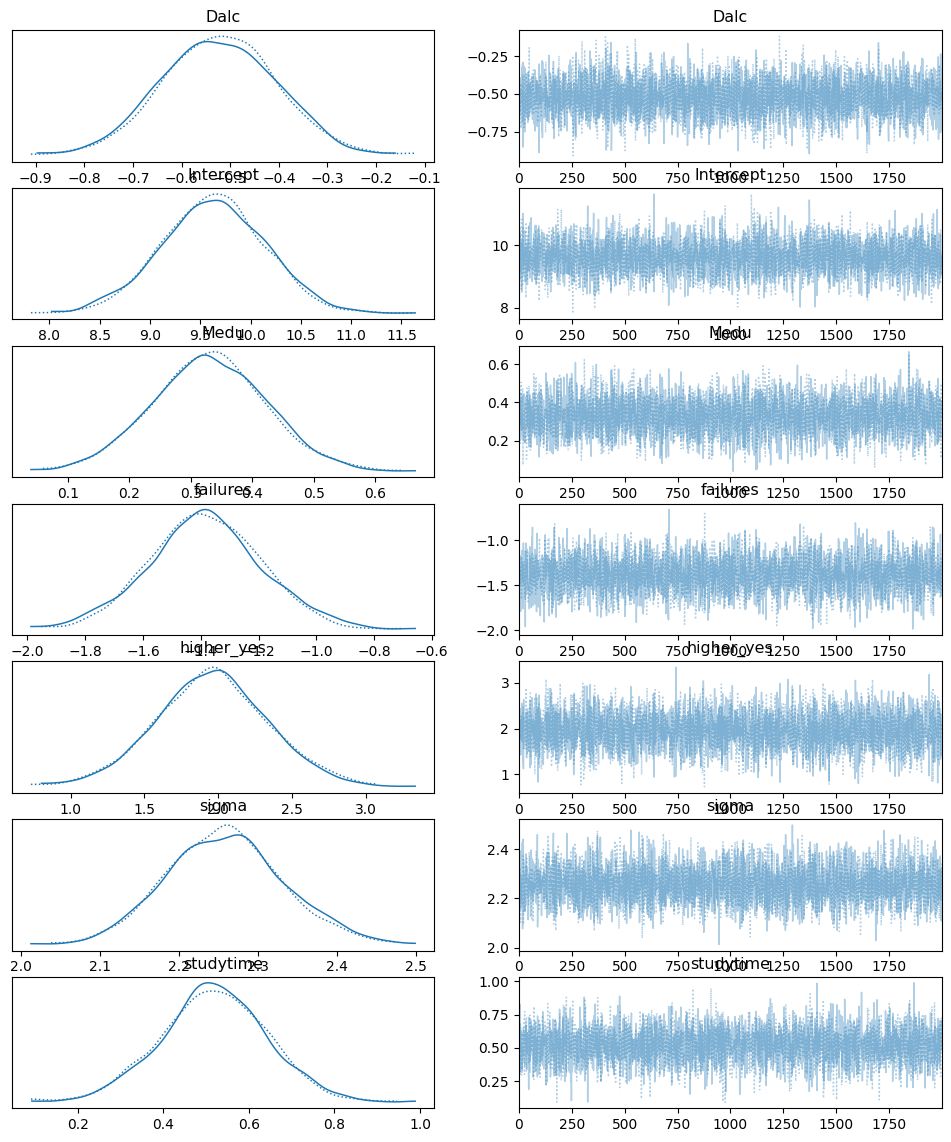

In [ ]:
# TODO: Generate trace plot
import arviz as az
az.plot_trace(results)


### Interpreting Trace Plots

Trace plots offer a visual summary of the posterior distributions and sampling behavior for each parameter in the model.

- **Left side (Marginal Posterior):**  
  This shows the estimated **posterior distribution** for each parameter. The x-axis represents parameter values, and the y-axis shows relative probability density, inferred from the MCMC samples. Multiple colored curves indicate different sampling **chains** — in this case, four chains.

- **Right side (Sampling Trace):**  
  This plot shows the **sample values** drawn for each parameter over the course of the sampling iterations. It helps assess **convergence** and **mixing**: well-behaved traces should appear like “fat fuzzy caterpillars” without visible trends or divergences.

Together, these plots help verify whether the chains converged and whether the posterior estimates are stable.

---

### Forest Plots for Summary

Another helpful visualization is the **forest plot**, which summarizes the **posterior distributions** of model parameters along with their **credible intervals**.


array([<Axes: title={'center': '95.0% HDI'}>], dtype=object)

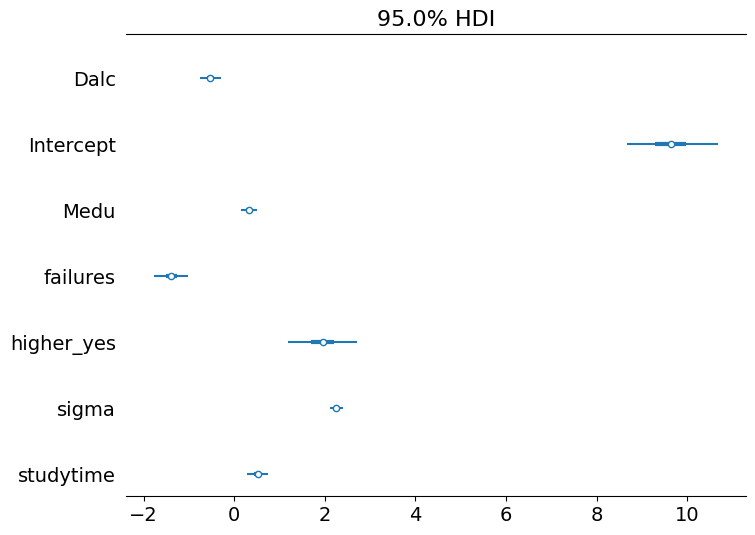

In [ ]:
# TODO: Generate forest plot
az.plot_forest(results, hdi_prob=0.95, figsize=(8, 6), combined=True)

### Interpreting the Forest Plot

**Questions:**

1. What does the dot and the horizontal line represent for each parameter in the forest plot?

2. Which parameters in your model show the most uncertainty, and how can you tell?

3. How would using the full posterior distribution (instead of just the mean or median) affect your predictions?

**Answer:** <span style="color:red">
1. In a forest plot, the dot represents the posterior mean or median of a parameter, serving as a point estimate of its likely value. It summarizes the central tendency of the posterior distribution.

  The horizontal line depicts the 95% Highest Density Interval (HDI), which indicates the range within which 95% of the posterior probability mass lies. This line provides a credible interval, showing the uncertainty associated with the parameter estimate.
2. Parameters that have wider 95% HDI bars (longer horizontal lines) indicate higher uncertainty in their estimates. The width reflects how much the posterior distribution spreads around the mean or median.

  In the plot, parameters like Intercept, failures, and higher_yes have relatively broad HDIs, signaling greater uncertainty compared to parameters such as sigma, which has narrower intervals and thus more precise estimates.
3. Relying on the full posterior distribution allows predictions to incorporate the full uncertainty of the parameter estimates. Rather than producing a single-point prediction, this approach generates probabilistic predictions with credible intervals.

  This can be particularly valuable in risk-sensitive contexts or when decisions must be made under uncertainty, as it gives a more complete picture of possible outcomes and their associated probabilities.
</span>**


When making predictions, we can:
- Use the **mean or median** of each posterior as a single point estimate.
- Or use the **full posterior distribution** to account for uncertainty in predictions.


### Density Plot for Posterior Distributions

Another useful visualization is the **density plot**, which shows a **smoothed estimate of the posterior distribution** for each continuous parameter (or a histogram for discrete ones).


array([[<Axes: title={'center': 'Dalc'}>,
        <Axes: title={'center': 'Intercept'}>,
        <Axes: title={'center': 'Medu'}>],
       [<Axes: title={'center': 'failures'}>,
        <Axes: title={'center': 'higher_yes'}>,
        <Axes: title={'center': 'sigma'}>],
       [<Axes: title={'center': 'studytime'}>, <Axes: >, <Axes: >]],
      dtype=object)

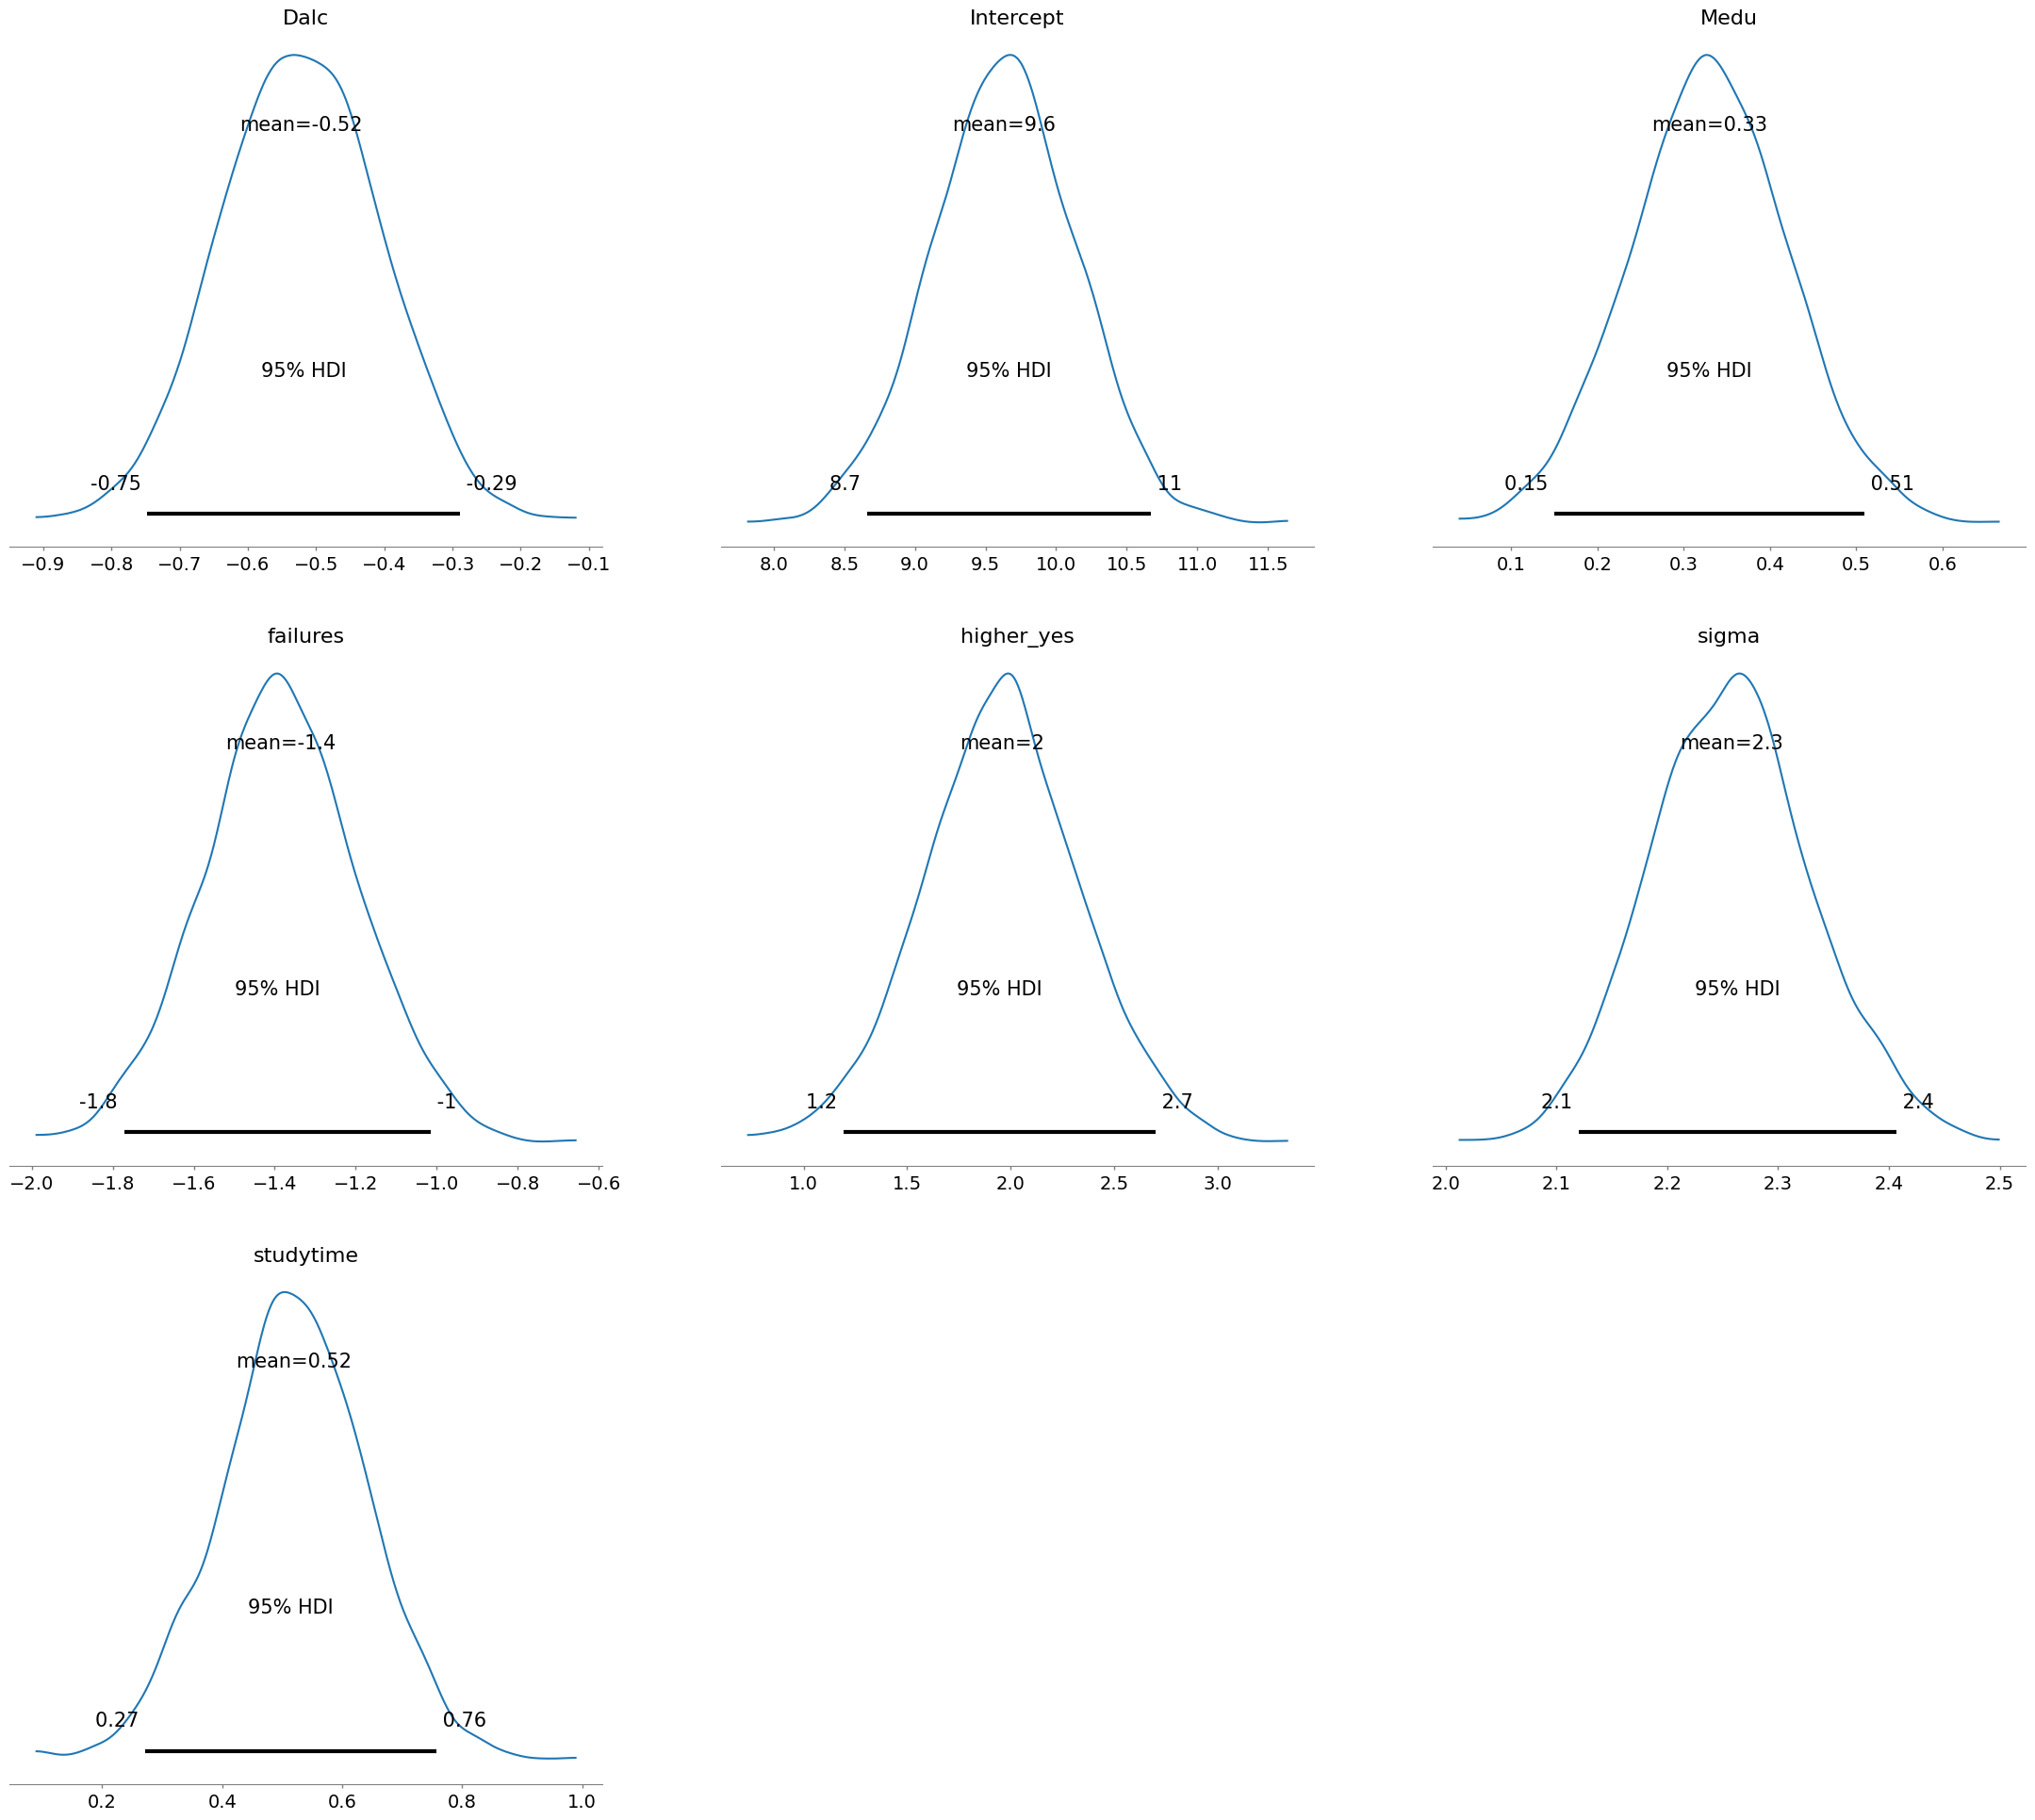

In [ ]:
# TODO: Plot the posterior distributions of the model parameters
az.plot_posterior(results, hdi_prob=0.95)

In [ ]:
posterior = results.posterior

for var in posterior.data_vars:
    values = posterior[var].values  # shape: (chains, draws, ...)
    mean_val = np.mean(values)
    print(f'Variable: {var:15} Mean weight in model: {mean_val:.4f}')


Variable: Dalc            Mean weight in model: -0.5226
Variable: Intercept       Mean weight in model: 9.6303
Variable: Medu            Mean weight in model: 0.3297
Variable: failures        Mean weight in model: -1.3851
Variable: higher_yes      Mean weight in model: 1.9560
Variable: sigma           Mean weight in model: 2.2578
Variable: studytime       Mean weight in model: 0.5185


### Interpretations of Weights

Based on the sign and location of the weights, we can make the following inferences regarding the features in our dataset:

* Previous class failures are negatively related to the students final grade
* Higher education ambitions are positively related to the students grade
* The mother's education level is positively related to the students final grade
* Studying time per week is positively related to the students final grade
* Alcohol consumption during the week is negatively related to the students final grade

## Linear Formula from Markov Chain Monte Carlo

In [ ]:
model_formula = 'y ~ '
for var in posterior.data_vars:
    model_formula += '(%0.4f * %s) + ' % (np.mean(posterior[var]), var)

' '.join(model_formula.split(' ')[:-2])

'y ~ (-0.5226 * Dalc) + (9.6303 * Intercept) + (0.3297 * Medu) + (-1.3851 * failures) + (1.9560 * higher_yes) + (2.2578 * sigma) + (0.5185 * studytime)'

In [ ]:
final_equation

'grade = 9.64 + 0.33 * Medu + 0.52 * studytime + -1.38 * failures + -0.52 * Dalc + 1.95 * higher_yes'

## Evaluate Bayesian Model Using Most Likely Values for Weights

Now, we can make predictions for students outcomes using the trace samples. To come up with a single estimate, we take the mean of all the parameter samples as the single value of the parameter.

In [ ]:
def evaluate_trace(trace, X_train, X_test, y_train, y_test, model_results):
    # Extract posterior samples
    posterior = trace.posterior  # InferenceData object

    # Compute means for parameters
    var_means = {}

    for var in posterior.data_vars:
        values = posterior[var].values  # shape: (chains, draws, ...) or (chains, draws)
        mean_val = np.mean(values, axis=(0, 1))  # Average over chains and draws

        if values.ndim == 2:  # scalar param (like intercept)
            var_means[var] = mean_val
        elif values.ndim == 3:  # vector param (like beta)
            for i, val in enumerate(mean_val):
                var_means[f"{var}_{i}"] = val

    # Create DataFrame from means
    means_series = pd.Series(var_means)

    # Ensure Intercept is added
    X_test = X_test.copy()
    X_test['Intercept'] = 1

    # Align columns to parameter names
    param_names = X_test.columns.tolist()
    try:
        weights = means_series[param_names].values
    except KeyError:
        # Try matching by index (for vectorized params like beta_0, beta_1, etc.)
        weights = np.array([means_series.get(name, 0) for name in param_names])

    # Estimate predictions
    estimates = X_test @ weights

    # Metrics
    actual = y_test.values if hasattr(y_test, "values") else y_test
    rmse = np.sqrt(mean_squared_error(estimates, actual))
    mape = np.median(np.abs(estimates - actual) / actual)

    print(f'Model RMSE: {rmse:.4f}\nModel MAPE: {mape:.4f}')

    # Plot predictions
    plt.figure(figsize=(10, 10))
    plt.scatter(X_test.index, actual, label='Observed', color='blue')
    plt.scatter(X_test.index, estimates, label='Estimate', color='red')
    plt.legend(prop={'size': 14})
    plt.xlabel('Index'); plt.ylabel('Grade')
    plt.title('Observed and Estimated Values')
    plt.show()

    # Add to results dataframe
    model_results.loc['Bayesian LM', :] = [rmse, mape]

    # Plot RMSE and MAPE comparison
    plt.figure(figsize=(12, 6))
    ax1 = plt.subplot(1, 2, 1)
    model_results.sort_values('rmse', ascending=True).plot.bar(y='rmse', color='b', ax=ax1)
    plt.title('Model RMSE Comparison'); plt.ylabel('RMSE')

    ax2 = plt.subplot(1, 2, 2)
    model_results.sort_values('mape', ascending=True).plot.bar(y='mape', color='r', ax=ax2)
    plt.title('Model MAPE Comparison'); plt.ylabel('MAPE')

    plt.tight_layout()
    plt.show()

    # Return results
    results_df = pd.DataFrame({'estimate': estimates}, index=X_test.index)
    return results_df

Model RMSE: 2.4470
Model MAPE: 0.1394


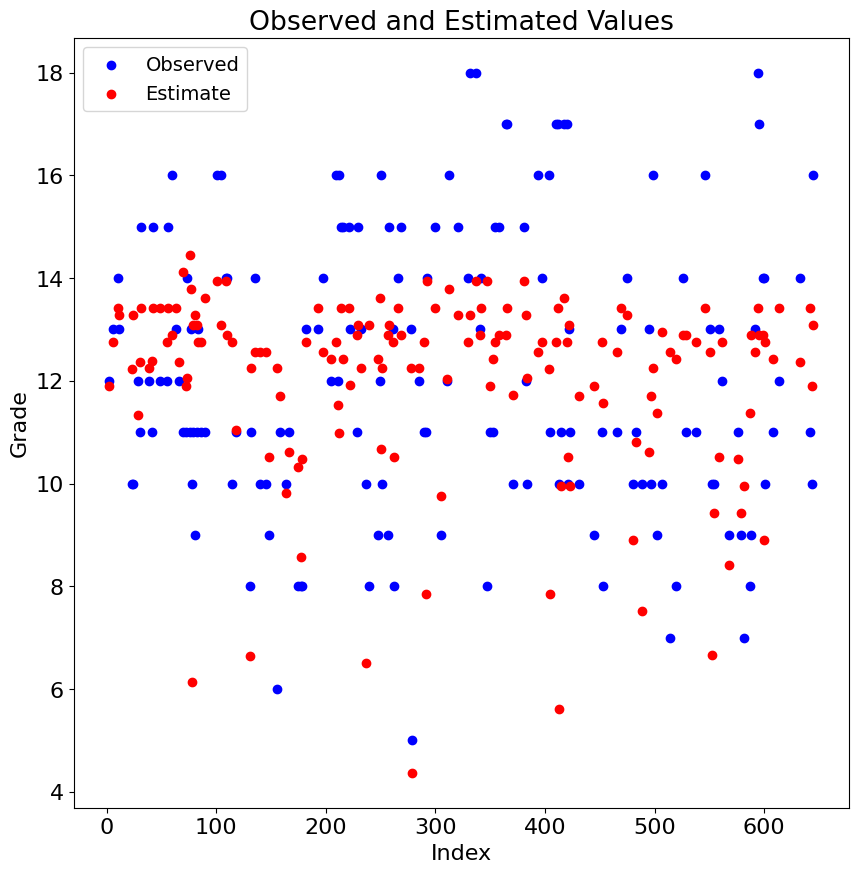

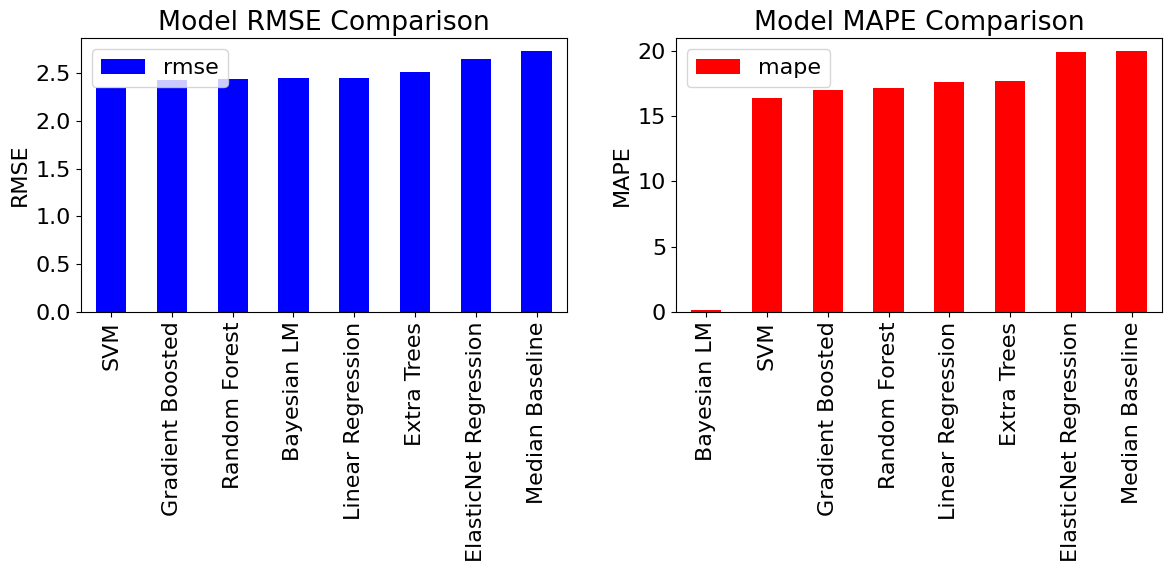

In [ ]:
final_results = evaluate_trace(results, X_train_math, X_test_math, y_train_math, y_test_math, math_results)

Our first attempt at creating a Bayesian Generalized Linear Model does not do that well in comparison to other models. To improve the model, we could draw more samples or try selecting additional features. However, there are other benefits to a Bayesian model such as uncertainty estimates that might make the tradeoff of slightly lower performance acceptable.


## Query Model

We can now make predictions from the model by passing in a new observation. As the trace contains every sample drawn from the posterior for every weight, we can calculate an entire range of estimates instead of a single number. This shows that there is uncertainty in our estimate.

In [ ]:
def query_model(trace, new_observation):
    posterior = trace.posterior

    # Flatten trace into samples (samples x parameters)
    n_chains, n_draws = posterior.dims['chain'], posterior.dims['draw']
    flat_samples = {}

    for var in posterior.data_vars:
        values = posterior[var].values  # shape: (chains, draws) or (chains, draws, dim)
        if values.ndim == 2:  # scalar (e.g. Intercept)
            flat_samples[var] = values.reshape(-1)
        elif values.ndim == 3:  # vector (e.g. beta[i])
            for i in range(values.shape[2]):
                flat_samples[f"{var}_{i}"] = values[:, :, i].reshape(-1)

    # Create DataFrame of all sampled weights
    var_weights = pd.DataFrame(flat_samples)

    # Align weights with the new observation
    param_names = new_observation.columns.tolist()
    weights = np.array([var_weights[col] if col in var_weights.columns else np.zeros(len(var_weights))
                        for col in param_names]).T  # shape: (samples, features)

    obs_array = new_observation.values.reshape(-1)  # shape: (features,)
    estimates = np.dot(weights, obs_array)  # shape: (samples,)

    # Plot distribution of estimates
    plt.figure(figsize=(8, 8))
    sns.histplot(estimates, kde=True, color='navy', edgecolor='black')
    plt.title('Density Plot for New Observation')
    plt.xlabel('Estimate'); plt.ylabel('Density')
    plt.show()

    # Print stats
    print('Average Estimate = %0.4f' % np.median(estimates))
    print('5%% Estimate = %0.4f    95%% Estimate = %0.4f' %
          (np.percentile(estimates, 5), np.percentile(estimates, 95)))

    return estimates

/tmp/ipython-input-3894607555.py:5: FutureWarning: The return type of `Dataset.dims` will be changed to return a set of dimension names in future, in order to be more consistent with `DataArray.dims`. To access a mapping from dimension names to lengths, please use `Dataset.sizes`.
  n_chains, n_draws = posterior.dims['chain'], posterior.dims['draw']


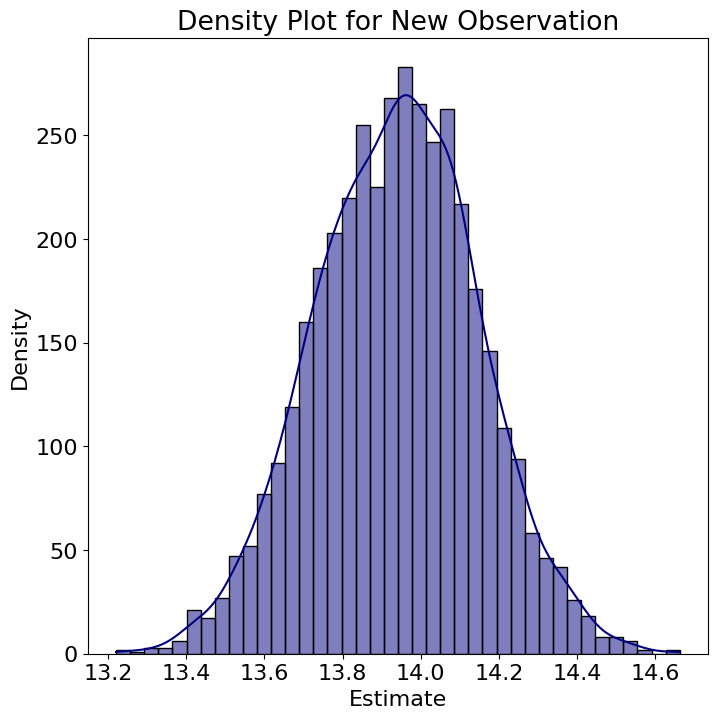

Average Estimate = 13.9438
5% Estimate = 13.5940    95% Estimate = 14.2735


In [ ]:
# TODO: Create a new observation for prediction
# Fill in the values for features like 'Intercept': 1, 'Medu': 4, 'failures': 0, 'higher_yes': 1, 'studytime': 3, 'Dalc': 1.
new_observation = pd.DataFrame([{
    'Intercept': 1, 'Medu': 4, 'failures': 0, 'higher_yes': 1, 'studytime': 3, 'Dalc': 1 }])

# TODO: Use the fitted Bayesian model to make predictions on the new observation
Estimate = query_model(results, new_observation)

/tmp/ipython-input-3894607555.py:5: FutureWarning: The return type of `Dataset.dims` will be changed to return a set of dimension names in future, in order to be more consistent with `DataArray.dims`. To access a mapping from dimension names to lengths, please use `Dataset.sizes`.
  n_chains, n_draws = posterior.dims['chain'], posterior.dims['draw']


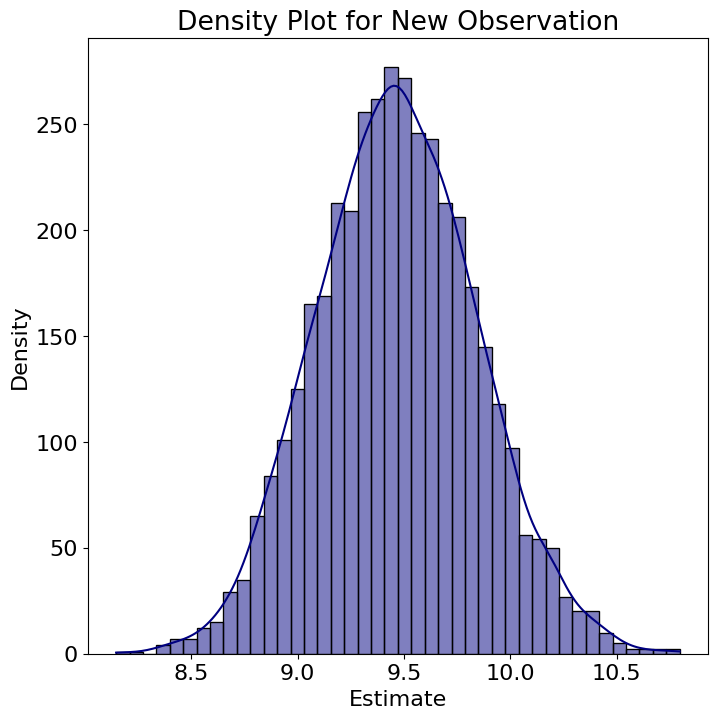

Average Estimate = 9.4622
5% Estimate = 8.8649    95% Estimate = 10.0902


In [ ]:
# TODO: Create a new observation for prediction
# Fill in the values for features like 'Intercept': 1, 'Medu': 2, 'failures': 2, 'higher_yes': 1, 'studytime': 2, 'Dalc': 2.
new_observation = pd.DataFrame([{
    'Intercept': 1, 'Medu': 2, 'failures': 2, 'higher_yes': 1, 'studytime': 2, 'Dalc': 2 }])

# TODO: Use the fitted Bayesian model to make predictions on the new observation
Estimate = query_model(results, new_observation)

The model estimations seem reasonable and are in line with our intuitions about what influences grades. Moreover, the model predictions take on a range of values which reflects the uncertainty in any real-world prediction. The benefit of Bayesian Inference is that we can show that uncertainty by displaying a range of possible answers instead of a single value.

## Student T Prior Distribution

In order to make our model more robust to outliers, we can use a different distribution, other than the default of normal, for the prior for the parameters. We can try the Student T Distribution, which has more weight in the tails, meaning the values further from the mean have a higher probability than in a Normal Distribution. This distribution should limit the effect of outliers on the model.

####  Normal Vs Student T Distribution

In [ ]:
import scipy.stats

In [ ]:
# X values for plotting
x = np.linspace(-5, 5, num = 500)

# Generate pdf of normal distribution
y_norm = scipy.stats.norm.pdf(x)

# PDF of t-distribution with 2 degrees of freedom
y_t = scipy.stats.t.pdf(x, df = 2)

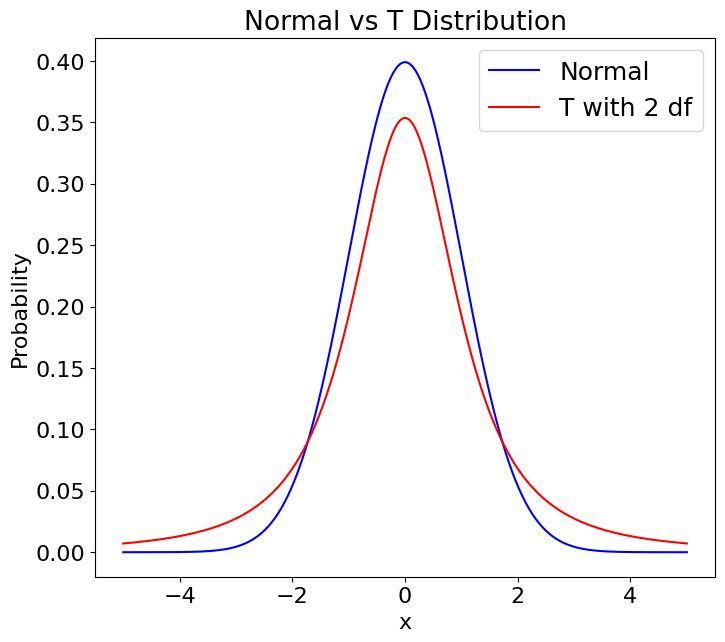

In [ ]:
plt.plot(x, y_norm, 'b-', label = 'Normal')
plt.plot(x, y_t, 'r-', label = 'T with 2 df')
plt.legend(prop = {'size': 18}, loc = 1)
plt.xlabel('x'); plt.ylabel('Probability'); plt.title('Normal vs T Distribution');

To modify the likelihood distribution in our model, we simply specify a different **family** when defining the model.

In PyMC (or Bambi), this can be done by setting the `family` argument. For example, instead of using the default **Normal (Gaussian)** distribution, we can switch to a **Student's t-distribution**, which is more robust to outliers due to its heavier tails.

In [ ]:
formula

'y ~ Medu + studytime + failures + Dalc + higher_yes'

In [ ]:
# TODO: Define the Bayesian model using a formula and the training data
# Use a Student-t likelihood for regression
model_t = bmb.Model(formula, X_train_math, family='t')

# TODO: Fit the model using MCMC sampling
results_t = model_t.fit(draws=NDRAWS, random_seed=42)

Output()

### Examine Samples from New Model

array([[<Axes: title={'center': 'Dalc'}>,
        <Axes: title={'center': 'Dalc'}>],
       [<Axes: title={'center': 'Intercept'}>,
        <Axes: title={'center': 'Intercept'}>],
       [<Axes: title={'center': 'Medu'}>,
        <Axes: title={'center': 'Medu'}>],
       [<Axes: title={'center': 'failures'}>,
        <Axes: title={'center': 'failures'}>],
       [<Axes: title={'center': 'higher_yes'}>,
        <Axes: title={'center': 'higher_yes'}>],
       [<Axes: title={'center': 'nu'}>, <Axes: title={'center': 'nu'}>],
       [<Axes: title={'center': 'sigma'}>,
        <Axes: title={'center': 'sigma'}>],
       [<Axes: title={'center': 'studytime'}>,
        <Axes: title={'center': 'studytime'}>]], dtype=object)

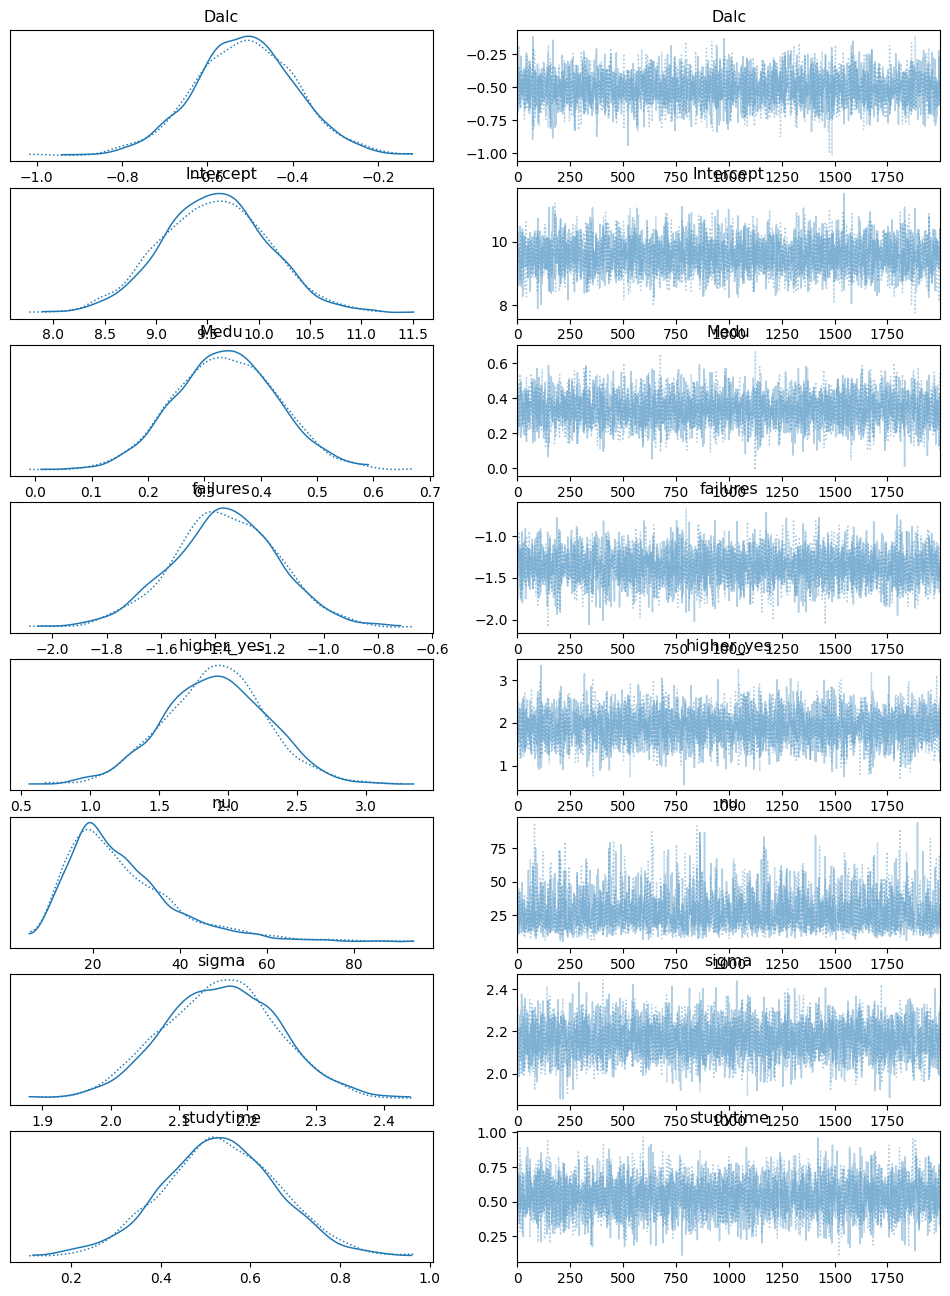

In [ ]:
# TODO: Generate trace plot
az.plot_trace(results_t)

array([<Axes: title={'center': '95.0% HDI'}>], dtype=object)

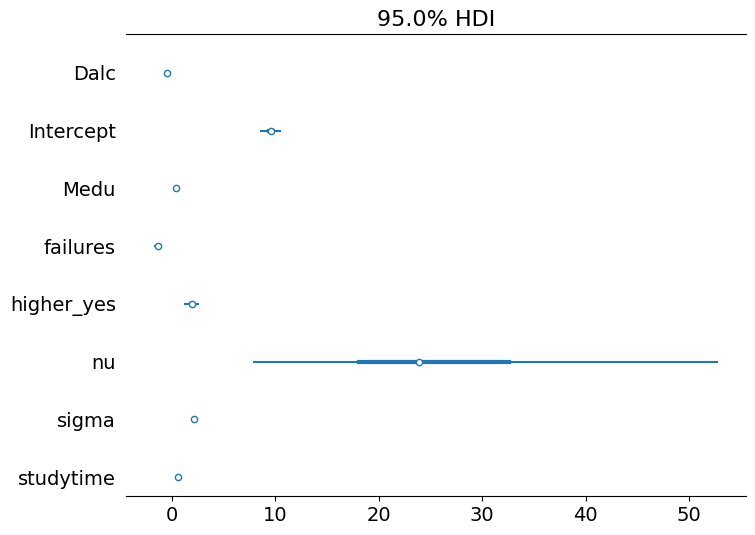

In [ ]:
# TODO: Generate forest plot
az.plot_forest(results_t, hdi_prob=0.95, figsize=(8, 6), combined=True)

**Question:** Which parameters in your model show the most uncertainty, and how can you tell?


**Answer:** This is clearly visible in the forest plot, where nu has a noticeably wider horizontal line, representing its 95% Highest Density Interval (HDI), compared to the other parameters. The broad interval indicates that the model is less certain about the true value of nu.

In contrast, parameters such as Intercept and higher_yes show much narrower HDIs. This suggests that their estimated values are more precise and that the model has greater confidence in these parameters..

## Evaluate the New Model

Model RMSE: 2.4416
Model MAPE: 0.1386


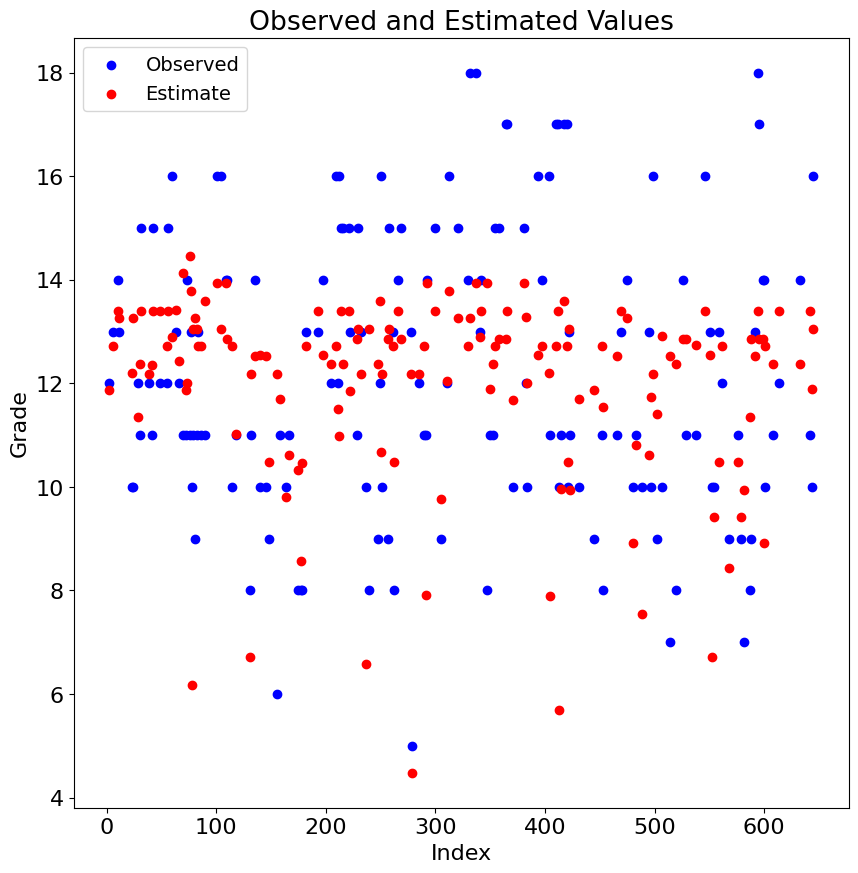

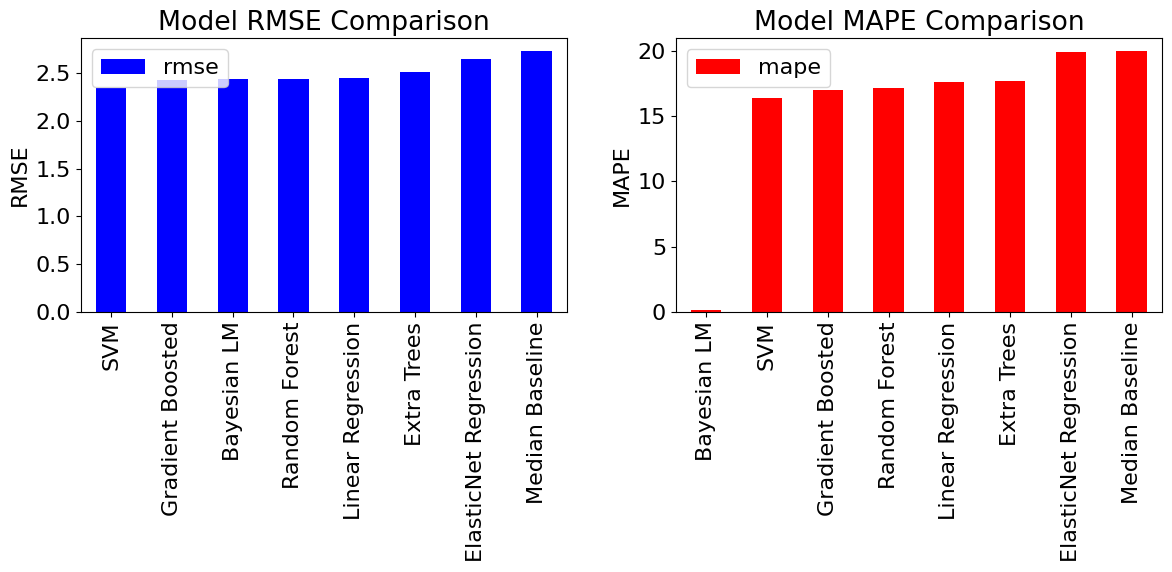

In [ ]:
results = evaluate_trace(results_t, X_train_math, X_test_math, y_train_math, y_test_math, math_results)

The t-distribution metrics are nearly identical to those from the normal distribution. As the number of samples/datapoints increases, the prior has less impact on the final results because the likelihoods come to dominate the parameters drawn from the posterior. We can do the same querying of the new model to view the predictions for observations from a new student. Again, we will plot the entire range of predicted values to show our uncertainty in the prediction.

### Query T-Distribution Model

/tmp/ipython-input-3894607555.py:5: FutureWarning: The return type of `Dataset.dims` will be changed to return a set of dimension names in future, in order to be more consistent with `DataArray.dims`. To access a mapping from dimension names to lengths, please use `Dataset.sizes`.
  n_chains, n_draws = posterior.dims['chain'], posterior.dims['draw']


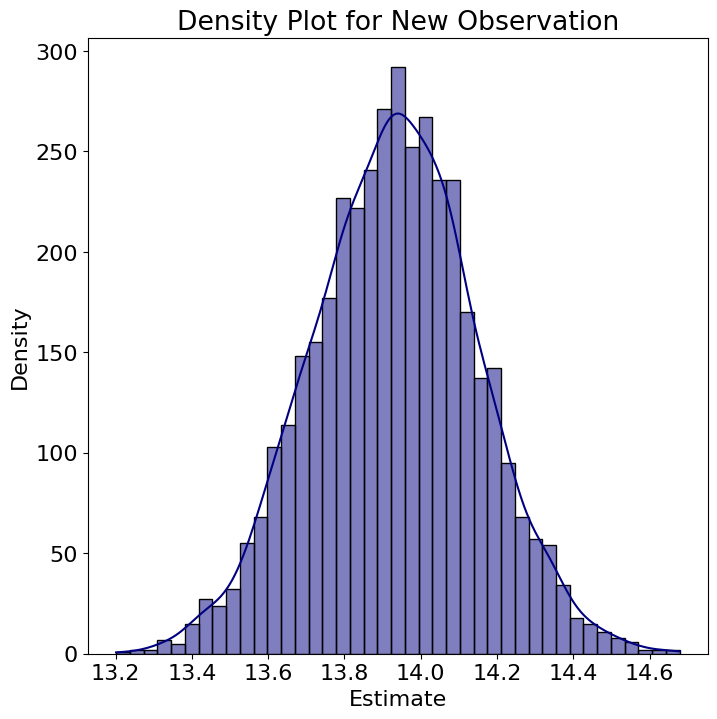

Average Estimate = 13.9347
5% Estimate = 13.5818    95% Estimate = 14.2867


In [ ]:
# TODO: Create a new observation for prediction
# Fill in the values for features like 'Intercept': 1, 'Medu': 4, 'failures': 0, 'higher_yes': 1, 'studytime': 3, 'Dalc': 1.
new_observation_t = pd.DataFrame([{
    'Intercept': 1, 'Medu': 4, 'failures': 0,'higher_yes': 1, 'studytime': 3, 'Dalc': 1 }])
# TODO: Use the fitted Bayesian model to make predictions on the new observation
Estimate_t = query_model(results_t, new_observation_t)

/tmp/ipython-input-3894607555.py:5: FutureWarning: The return type of `Dataset.dims` will be changed to return a set of dimension names in future, in order to be more consistent with `DataArray.dims`. To access a mapping from dimension names to lengths, please use `Dataset.sizes`.
  n_chains, n_draws = posterior.dims['chain'], posterior.dims['draw']


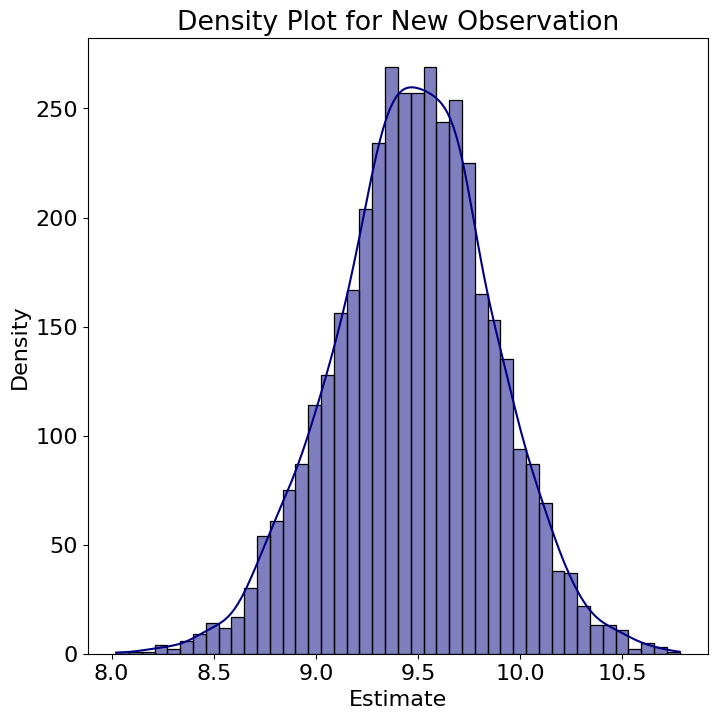

Average Estimate = 9.4863
5% Estimate = 8.8254    95% Estimate = 10.1059


In [ ]:
# TODO: Create a new observation for prediction
# Fill in the values for features like 'Intercept': 1, 'Medu': 2, 'failures': 2, 'higher_yes': 1, 'studytime': 2, 'Dalc': 2.
new_observation_t = pd.DataFrame([{
    'Intercept': 1, 'Medu': 2, 'failures': 2,'higher_yes': 1, 'studytime': 2, 'Dalc': 2 }])
# TODO: Use the fitted Bayesian model to make predictions on the new observation
Estimate_t = query_model(results_t, new_observation_t)

In [ ]:
posterior = results_t.posterior

model_formula = 'y ~ '
for var in posterior.data_vars:
    model_formula += '(%0.4f * %s) + ' % (np.mean(posterior[var]), var)

' '.join(model_formula.split(' ')[:-2])

'y ~ (-0.5107 * Dalc) + (9.5746 * Intercept) + (0.3392 * Medu) + (-1.3642 * failures) + (1.9090 * higher_yes) + (26.7223 * nu) + (2.1616 * sigma) + (0.5341 * studytime)'

### Comparing Priors: Normal vs. Student-t

We observe some differences between the results from the **Student-t distribution** and those from the **Normal distribution**. While both yield reasonable estimates, the Student-t prior is often preferred when the data contains **outliers** or exhibits **non-Gaussian behavior**, due to its heavier tails.

Although we could explore additional prior distributions, we limit our comparison here to Normal and Student-t for simplicity.

> Choosing appropriate priors is one of the most challenging aspects of Bayesian modeling.

However, this challenge can be mitigated by increasing the amount of training data. As more data is observed, the influence of the prior diminishes because the posterior becomes increasingly data-driven. In other words, **with enough data, Bayesian models behave similarly to traditional machine learning models**, where learning is dominated by the data rather than prior assumptions.

This is why Bayesian methods often excel in **low-data settings**, where they can incorporate prior beliefs to improve estimation and generalization — provided that the priors are sensible.

---

## Conclusions

In this part, we applied **Bayesian Linear Regression** to predict student performance based on several input features. Rather than explicitly define a probabilistic graphical model — which is difficult with continuous variables — we approached the task from a machine learning perspective.

We used the `bambi` library (based on PyMC) to:

- Build probabilistic regression models using both **Normal** and **Student-t** likelihoods.
- Sample from the posterior using **Markov Chain Monte Carlo (MCMC)** methods.

### Key Benefits of Bayesian Linear Regression:
- Produces **posterior distributions** over model parameters, not just point estimates.
- Allows for **uncertainty quantification** in predictions.
- Can perform well with **small datasets**, assuming appropriate priors.

While Bayesian Linear Regression did **not outperform traditional ML models** based on RMSE and MAPE metrics in this case, it still provided:
- Interpretable parameter estimates,
- Intuitive uncertainty measures,
- A framework for probabilistic reasoning.

### Final Thoughts:
Bayesian methods might not always be the best-performing option for every problem, but they offer **valuable insights and flexibility**, particularly when:
- Data is limited,
- Interpretability and uncertainty are important,
- Prior domain knowledge can be encoded into the model.

By learning and applying Bayesian approaches, we expand our toolkit and become better prepared for the wide variety of modeling challenges we may encounter.

# **Section2:** Bayesian Deep Learning via Dropout **<span style="color:green">(Extra Bonus)</span>**

## 1. Introduction

Bayesian inference provides a principled framework for capturing uncertainty in deep learning models. However, exact inference in neural networks is computationally intractable. **MC Dropout** offers an efficient approximation that enables us to treat standard neural networks with dropout as approximate Bayesian models. This section explores the theoretical underpinnings of this approach, particularly in the context of regression tasks.

---

## 2. Standard Neural Network for Regression

Consider a neural network with a single hidden layer. For an input $ x $, the network's output is:
$
\widehat{y} = \sigma(x W_1 + b) W_2
$

where:
- $ W_1 $ and $ W_2 $ are weight matrices,
- $ b $ is the bias vector,
- $ \sigma(\cdot) $ is an activation function (e.g., ReLU or tanh).

---

## 3. Dropout as a Bayesian Approximation

In the dropout-enhanced version of this network:
- Two binary dropout masks $ z_1 $ and $ z_2 $ are sampled from Bernoulli distributions.
- Each element of $ z_i $ is 1 with probability $ p_i $, and 0 with probability $ 1 - p_i $.

Given input $ x $, the forward pass becomes:

$
\widehat{y} = \sigma(x \odot z_1 W_1 + b) \odot z_2 W_2
$

During training, new dropout masks are sampled for each input and each forward pass. In the backward pass, the same dropout masks are reused. To preserve output magnitude, the weights are scaled by $ \frac{1}{p_i} $.

---

## 4. Dropout Objective Function

For regression, we typically use the Euclidean (MSE) loss:

$
E = \frac{1}{2N} \sum_{n=1}^N \| y_n - \widehat{y}_n \|^2_2
$

Adding L2 regularization (with weight decay $ \lambda_{\text{decay}} $), the training objective becomes:

$
L_{\text{dropout}} := E + \lambda_{\text{decay}} \left( \| W_1 \|^2_2 + \| W_2 \|^2_2 + \| b \|^2_2 \right)
$

At test time, dropout is disabled and the full weight matrices are used.

---

## 5. Dropout and Gaussian Process Approximation

By viewing our network as a Gaussian process (GP), we place a joint Gaussian prior over function values:

$
F \mid X \sim \mathcal{N}(z, K(X, X)), \quad Y \mid F \sim \mathcal{N}(F, \tau^{-1} I_N)
$

Here:
- $ \tau $ is a precision hyperparameter,
- $ K(x, y) $ is a kernel function,
- $ I_N $ is the $ N \times N $ identity matrix.

### 5.1 GP Kernel as a Neural Network Approximation

We define a GP kernel as:

$
K(x, y) = \int \mathcal{N}(w; 0, l^{-2}I_Q) \, p(b) \, \sigma(w^T x + b) \, \sigma(w^T y + b) \, dw \, db
$

This is approximated via Monte Carlo integration:

$
\hat{K}(x, y) = \frac{1}{K} \sum_{k=1}^K \sigma(w_k^T x + b_k) \sigma(w_k^T y + b_k)
$

where:
- $ w_k \sim \mathcal{N}(0, l^{-2} I_Q) $,
- $ b_k \sim p(b) $.

The number of terms $ K $ corresponds to the number of hidden units in the network.

---

## 6. Variational Approximation and KL Divergence

We approximate the posterior over weights with a variational distribution:

$
q_\theta(W_1) = \prod_{q=1}^Q q_\theta(w_q), \quad q_\theta(w_q) = p_1 \mathcal{N}(m_q, \sigma^2 I_K) + (1 - p_1) \mathcal{N}(0, \sigma^2 I_K)
$

This defines a **mixture of Gaussians** where the standard deviation $ \sigma $ is small (e.g., machine epsilon), ensuring a finite KL divergence.

The variational lower bound (ELBO) is:

$
L_{\text{VI}} := \int q_\theta(w) \log p(Y \mid X, w) \, dw - KL(q_\theta(w) \| p(w))
$

---

## 7. Monte Carlo Objective

Using a single MC sample $ \widehat{w} \sim q_\theta(w) $, the GP-inspired MC Dropout objective becomes:

$
L_{\text{GP-MC}} \approx \log p(Y \mid X, \widehat{w}) - \frac{p_1 l^2}{2} \| M_1 \|^2_2 - \frac{p_2 l^2}{2} \| M_2 \|^2_2 - \frac{l^2}{2} \| m \|^2_2
$

This is an unbiased estimator of the ELBO.

---

## 8. Scaling and Final Objective

After scaling the objective by $ \frac{1}{N \tau} $, we get:

$
L_{\text{GP-MC}} \propto - \frac{1}{2N} \sum_{n=1}^N \| y_n - \widehat{y}_n \|^2_2 - \frac{p_1 l^2}{2 N \tau} \| M_1 \|^2_2 - \frac{p_2 l^2}{2 N \tau} \| M_2 \|^2_2 - \frac{l^2}{2 N \tau} \| m \|^2_2
$

This closely resembles the dropout training objective when suitable values for $ \tau $ and $ l $ are chosen.

---


In [ ]:
import torch
import torch.nn as nn
import torch.nn.functional as F
import pandas as pd
import numpy as np
import math
import torch.optim as optim
from torch.autograd import Variable
import matplotlib.pyplot as plt
from torchvision import datasets, transforms

# Set device for training
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")


In [ ]:
class SimpleModel(torch.nn.Module):
    def __init__(self, dropout_rate, decay):
        super(SimpleModel, self).__init__()
        # TODO: Define a neural network with two hidden layers.
        # Use ReLU activation and Dropout after each hidden layer.
        # Final layer should map to a single output for regression.
        # First layer
        self.fc1 = nn.Linear(1, 100)
        self.dropout1 = nn.Dropout(p=dropout_rate)
        # Second layer
        self.fc2 = nn.Linear(100, 100)
        self.dropout2 = nn.Dropout(p=dropout_rate)
        # Output
        self.fc3 = nn.Linear(100, 1)
        self.decay = decay  # L2 regularization weight

    def forward(self, x):
        # TODO: Implement the forward pass using the defined layers.
        x = F.relu(self.fc1(x))
        x = self.dropout1(x)
        x = F.relu(self.fc2(x))
        x = self.dropout2(x)
        return self.fc3(x)

In [ ]:
def uncertainity_estimate(x, model, num_samples, l2):
    # TODO: Use MC Dropout to sample predictions multiple times.
    # Calculate mean and variance of predictions.
    # Apply model uncertainty adjustment using tau.
    # Return both mean and standard deviation of predictions.
    model.train()
    x = x.to(next(model.parameters()).device)
    preds = []
    with torch.no_grad():
        for i in range(num_samples):
            y_hat = model(x)
            preds.append(y_hat)
    preds = torch.stack(preds)
    mean = preds.mean(dim=0)
    Var = preds.var(dim=0)
    l = 1.0
    tau = 1.0 / (l**2 *l2)
    Var_T = Var + (1.0/ tau)
    std = torch.sqrt(Var_T)
    return mean, std

In [ ]:
# TODO: Define a training loop using MSE loss and SGD optimizer.
# Train the model on the generated dataset.
# Print training loss every few thousand iterations.
N = 100
X_train = np.random.uniform(-2, 2, size=(N, 1))
Y_train = np.sin(X_train) + 0.1 * np.random.randn(N, 1)

X_train_tensor = torch.tensor(X_train, dtype=torch.float32).to(device)
Y_train_tensor = torch.tensor(Y_train, dtype=torch.float32).to(device)


dropout_rate = 0.1
decay = 1e-2
model = SimpleModel(dropout_rate, decay).to(device)

optimizer = optim.SGD(model.parameters(), lr=0.01)
criterion = nn.MSELoss()

epochs = 10000
for i in range(epochs + 1):
    model.train()
    optimizer.zero_grad()
    output = model(X_train_tensor)
    loss = criterion(output, Y_train_tensor)

    l2_reg = sum(param.norm(2)**2 for param in model.parameters())
    loss = loss + decay * l2_reg

    loss.backward()
    optimizer.step()

    if i % 1000 == 0:
        print(f"Iter: {i}, Loss: {loss.item():.4f}")


Iter: 0, Loss: 1.5278
Iter: 1000, Loss: 0.6532
Iter: 2000, Loss: 0.4514
Iter: 3000, Loss: 0.3152
Iter: 4000, Loss: 0.2225
Iter: 5000, Loss: 0.1680
Iter: 6000, Loss: 0.1211
Iter: 7000, Loss: 0.0977
Iter: 8000, Loss: 0.0801
Iter: 9000, Loss: 0.0717
Iter: 10000, Loss: 0.0643


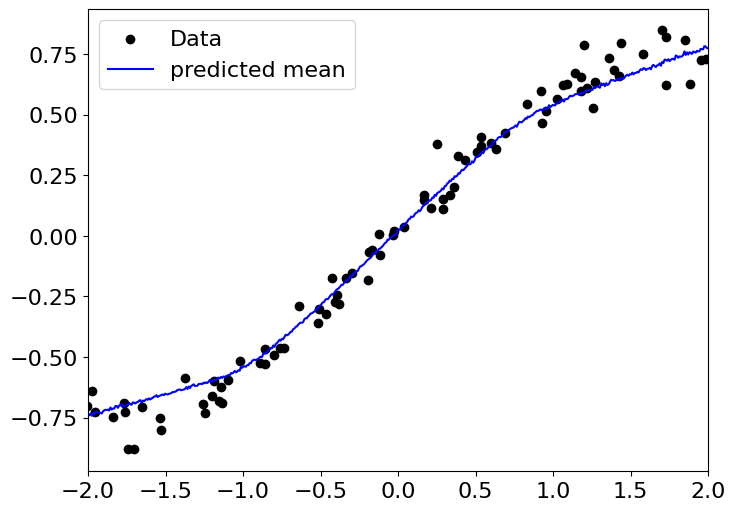

In [ ]:
# TODO: Evaluate the model on training data.
# Plot original noisy data and the model’s predicted curve.
model.train()
X_mean = X_train.mean()
X_std = X_train.std()
Y_mean = Y_train.mean()
Y_std = Y_train.std()
x_test = np.linspace(-2, 2, 500).reshape(-1, 1)
x_test_normal = (x_test - X_mean) / X_std
x_test_tensor = torch.tensor(x_test_normal, dtype=torch.float32).to(device)

N = 200
preds = []
for i in range(N):
    with torch.no_grad():
        pred = model(x_test_tensor)
        preds.append(pred.cpu().numpy())
preds = np.array(preds)
pred_mean = preds.mean(axis=0).squeeze()
pred_mean = pred_mean * Y_std + Y_mean
plt.figure(figsize=(8, 6))
plt.scatter(X_train * X_std + X_mean, Y_train * Y_std + Y_mean,
            color='black', label='Data')
plt.plot(x_test, pred_mean, color='blue', label='predicted mean')
plt.xlim(-2, 2)
plt.legend()
plt.show()


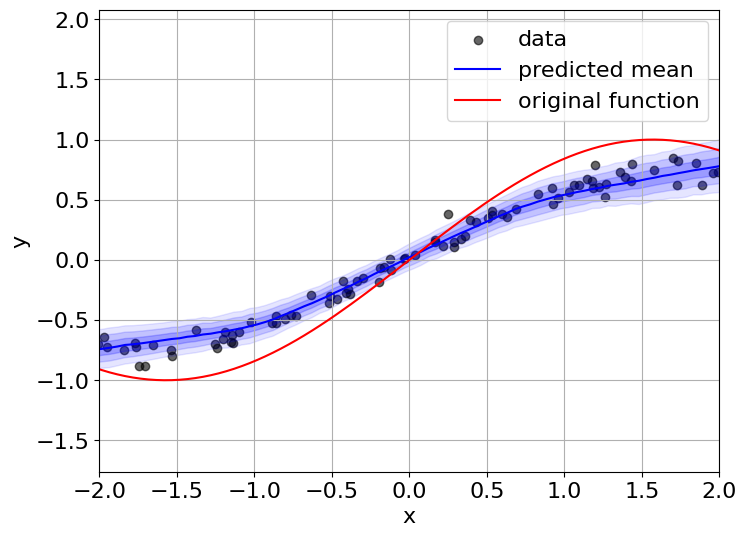

In [ ]:
# TODO: Estimate model predictions and uncertainty using MC Dropout.
# Plot predicted mean and multiple confidence intervals (1σ, 2σ, ...).
# Overlay the true function and training data.
model.train()
x_test = np.linspace(-5, 5, 200).reshape(-1, 1)
x_test_norm = (x_test - X_mean) / X_std
x_test_tensor = torch.tensor(x_test_norm, dtype=torch.float32).to(device)
N = 1000
preds = []
for i in range(N):
    with torch.no_grad():
        pred = model(x_test_tensor)
        preds.append(pred.cpu().numpy())

preds = np.array(preds)
pred_mean = preds.mean(axis=0).squeeze()
pred_std = preds.std(axis=0).squeeze()
# normal to orginal
pred_mean = pred_mean * Y_std + Y_mean
pred_std = pred_std * Y_std
original_function = np.sin(x_test)
plt.figure(figsize=(8, 6))
plt.scatter(X_train * X_std + X_mean, Y_train * Y_std + Y_mean,
            color='black', label='data', alpha=0.6)
plt.plot(x_test, pred_mean, color='blue', label='predicted mean')
plt.plot(x_test, original_function, color='red', label='original function')

# Uncertainty
for i, alpha in zip([3, 2, 1], [0.1, 0.15, 0.2]):
    plt.fill_between(x_test.flatten(), pred_mean - i * pred_std, pred_mean + i * pred_std, color='blue', alpha=alpha)

plt.legend()
plt.xlabel("x")
plt.xlim(-2, 2)
plt.ylabel("y")
plt.grid()
plt.show()


In [ ]:
# TODO: Load and normalize the MNIST dataset using torchvision.
# Create DataLoader objects for training and testing.
torch.manual_seed(42)
np.random.seed(42)
transform = transforms.Compose([
    transforms.ToTensor(),
    transforms.Normalize((0.1307,), (0.3081,))
])
dataset_train = datasets.MNIST(root='./data', train=True, download=True, transform=transform)
dataset_test  = datasets.MNIST(root='./data', train=False, download=True, transform=transform)

train_loader = torch.utils.data.DataLoader(
    dataset=dataset_train, batch_size=64, shuffle=True, num_workers=2, pin_memory=True
)
test_loader = torch.utils.data.DataLoader(
    dataset=dataset_test, batch_size=1000, shuffle=False, num_workers=2, pin_memory=True
)


In [ ]:
class CNN_Model(nn.Module):
    def __init__(self):
        super(CNN_Model, self).__init__()
        # TODO: Define a CNN architecture with two convolutional layers,
        # followed by dropout, ReLU, max-pooling, and two fully connected layers.
        self.conv1 = nn.Conv2d(1, 32, kernel_size=3, padding=1)
        self.conv2 = nn.Conv2d(32, 64, kernel_size=3, padding=1)
        self.pool = nn.MaxPool2d(2, 2)
        self.fc1 = nn.Linear(64 * 7 * 7, 128)
        self.fc2 = nn.Linear(128, 10)

    def forward(self, x):
        # TODO: Implement forward pass with dropout activated even during inference.
        x = F.relu(self.conv1(x))
        x = self.pool(x)
        x = F.dropout(x, p=0.25, training=True)

        x = F.relu(self.conv2(x))
        x = self.pool(x)
        x = F.dropout(x, p=0.25, training=True)

        x = x.view(x.size(0), -1)
        x = F.relu(self.fc1(x))
        x = F.dropout(x, p=0.5, training=True)

        return self.fc2(x)


In [ ]:
# TODO: Train the CNN using cross-entropy loss and SGD optimizer.
# Print training loss every few batches to monitor progress.
model = CNN_Model().to(device)
criterion = nn.CrossEntropyLoss()
optimizer = optim.SGD(model.parameters(), lr=0.01, momentum=0.9, weight_decay=1e-4)
epochs = 5
for i in range(epochs):
    model.train()
    running_loss = 0.0
    running_correct = 0
    running_total = 0

    for batch_idx, (images, labels) in enumerate(train_loader):
        images, labels = images.to(device), labels.to(device)
        outputs = model(images)
        loss = criterion(outputs, labels)
        optimizer.zero_grad()
        loss.backward()
        optimizer.step()
        running_loss += loss.item()
        _, predicted = outputs.max(1)
        running_correct += predicted.eq(labels).sum().item()
        running_total += labels.size(0)

        if (batch_idx + 1) % 100 == 0:
            avg_loss = running_loss / 100
            avg_acc = 100.0 * running_correct / running_total
            print(f"Epoch [{i+1}/{epochs}], Step [{batch_idx+1}/{len(train_loader)}], "
                  f"Loss: {avg_loss:.4f}, Accuracy: {avg_acc:.2f}%")
            running_loss = 0.0
            running_correct = 0
            running_total = 0


Epoch [1/5], Step [100/938], Loss: 1.2222, Accuracy: 58.31%
Epoch [1/5], Step [200/938], Loss: 0.4428, Accuracy: 86.09%
Epoch [1/5], Step [300/938], Loss: 0.2920, Accuracy: 90.80%
Epoch [1/5], Step [400/938], Loss: 0.2149, Accuracy: 93.33%
Epoch [1/5], Step [500/938], Loss: 0.2220, Accuracy: 93.30%
Epoch [1/5], Step [600/938], Loss: 0.1693, Accuracy: 95.08%
Epoch [1/5], Step [700/938], Loss: 0.1764, Accuracy: 94.58%
Epoch [1/5], Step [800/938], Loss: 0.1639, Accuracy: 95.16%
Epoch [1/5], Step [900/938], Loss: 0.1345, Accuracy: 96.06%
Epoch [2/5], Step [100/938], Loss: 0.1243, Accuracy: 96.47%
Epoch [2/5], Step [200/938], Loss: 0.1284, Accuracy: 96.03%
Epoch [2/5], Step [300/938], Loss: 0.1308, Accuracy: 96.17%
Epoch [2/5], Step [400/938], Loss: 0.1196, Accuracy: 96.11%
Epoch [2/5], Step [500/938], Loss: 0.1128, Accuracy: 96.88%
Epoch [2/5], Step [600/938], Loss: 0.1141, Accuracy: 96.48%
Epoch [2/5], Step [700/938], Loss: 0.1119, Accuracy: 96.53%
Epoch [2/5], Step [800/938], Loss: 0.098

In [ ]:
def test(model):
    # TODO: Evaluate the trained CNN on the MNIST test set.
    # Calculate accuracy and average test loss.
    model.eval()
    total_loss = 0.0
    correct = 0
    total = 0
    criterion = nn.CrossEntropyLoss(reduction='sum')

    with torch.no_grad():
        for image, label in test_loader:
            image, label = image.to(device), label.to(device)
            outputs = model(image) if not mc_dropout else model(image)  # could add training=True inside forward
            loss = criterion(outputs, label)
            total_loss += loss.item()
            _, predicted = torch.max(outputs, 1)
            total += label.size(0)
            correct += (predicted == label).sum().item()

    avg_test_loss = total_loss / total
    accuracy = 100 * correct / total
    print(f"Test set: Average loss: {avg_loss:.4f}, Accuracy: {correct}/{total} ({accuracy:.2f}%)")
    return avg_test_loss, accuracy


In [ ]:
def mcdropout_test(model):
    # TODO: Run MC Dropout multiple times on each test sample.
    # Average the outputs and compute classification accuracy.
    model.train()
    correct = 0
    total_loss = 0.0

    with torch.no_grad():
        for image, label in test_loader:
            image, label = image.to(device), label.to(device)
            probs = torch.zeros(image.shape[0], 10, T).to(device)
            for i in range(T):
                outputs = model(image)
                probs[:, :, i] = F.softmax(outputs, dim=1)
            mean_probs = probs.mean(dim=2)
            total_loss += F.cross_entropy(mean_probs.log(), label, reduction='sum').item()
            pred = mean_probs.argmax(dim=1)
            correct += pred.eq(label).sum().item()

    avg_loss = total_loss / len(test_loader.dataset)
    accuracy = 100. * correct / len(test_loader.dataset)
    print(f"MC Dropout Test set: Average loss: {avg_loss:.4f}, Accuracy: {correct}/{len(test_loader.dataset)} ({accuracy:.2f}%)")



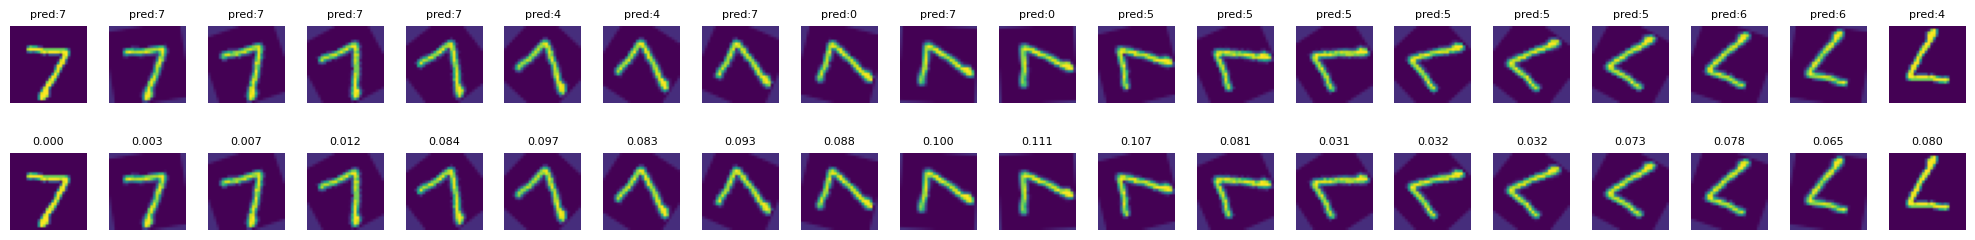

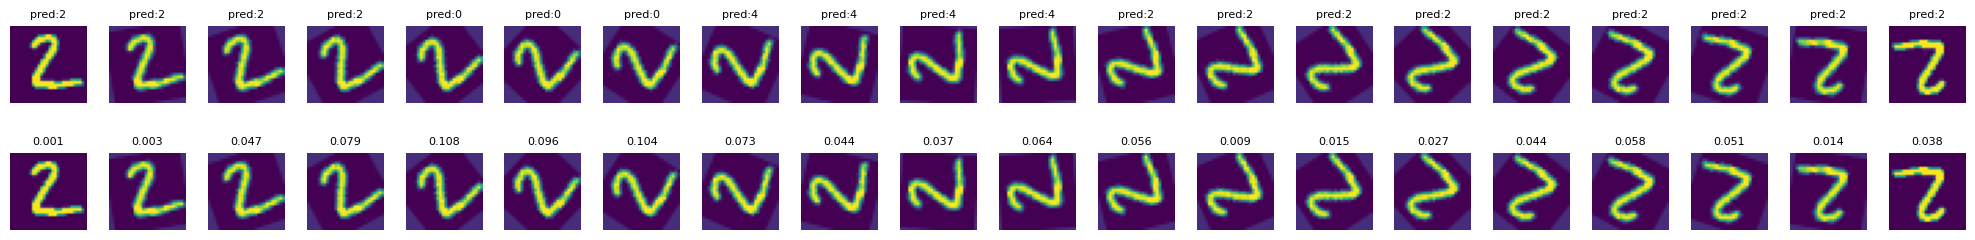

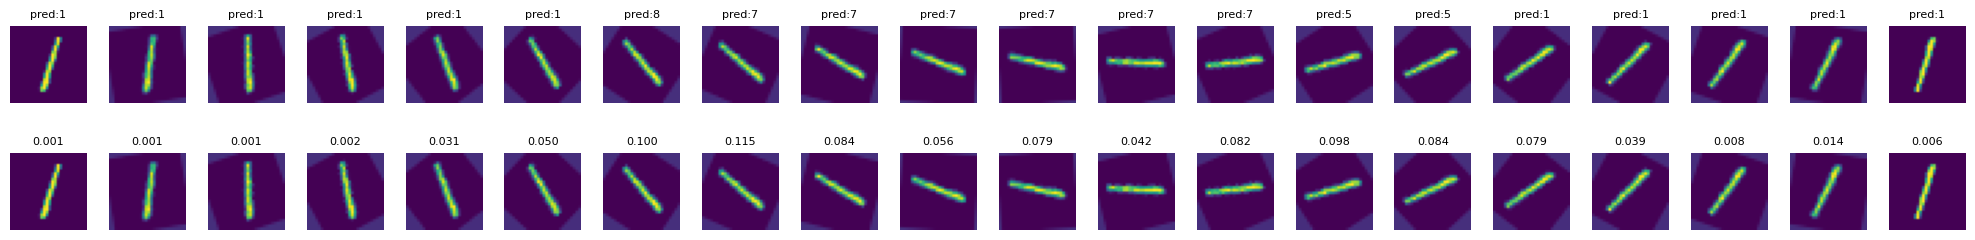

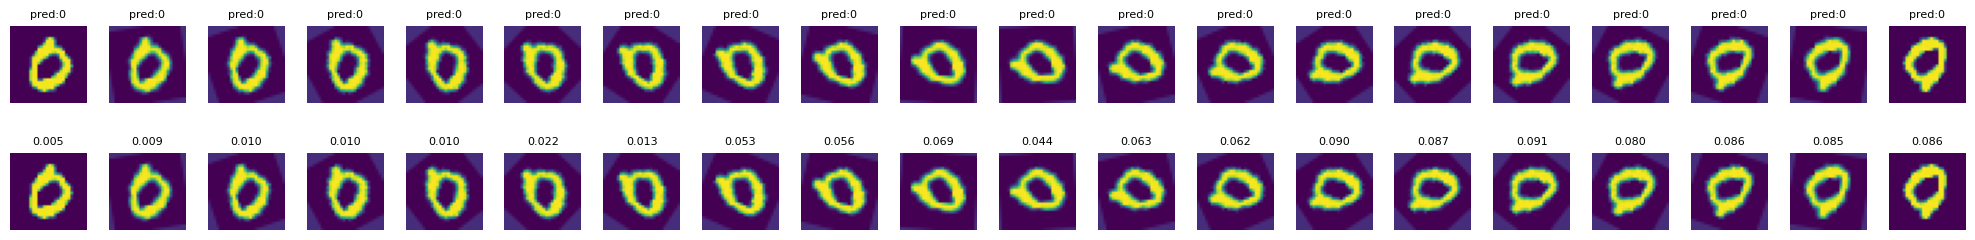

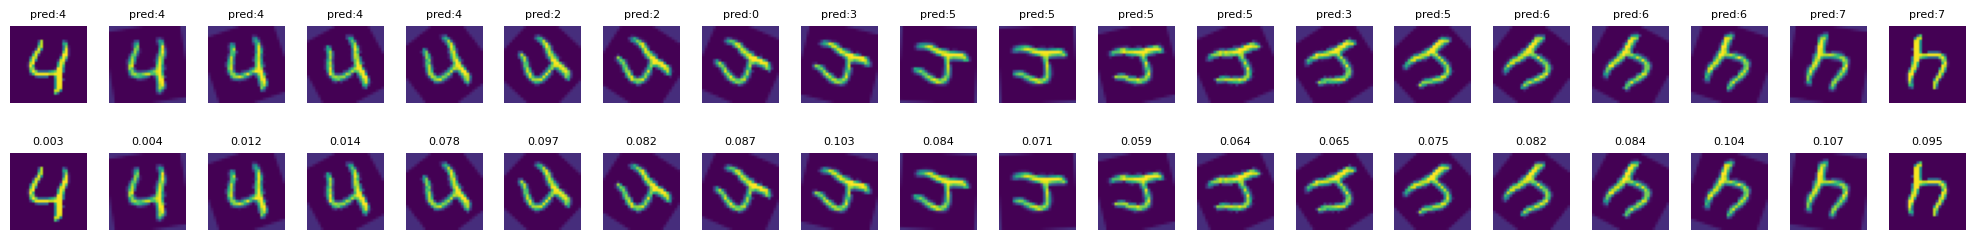

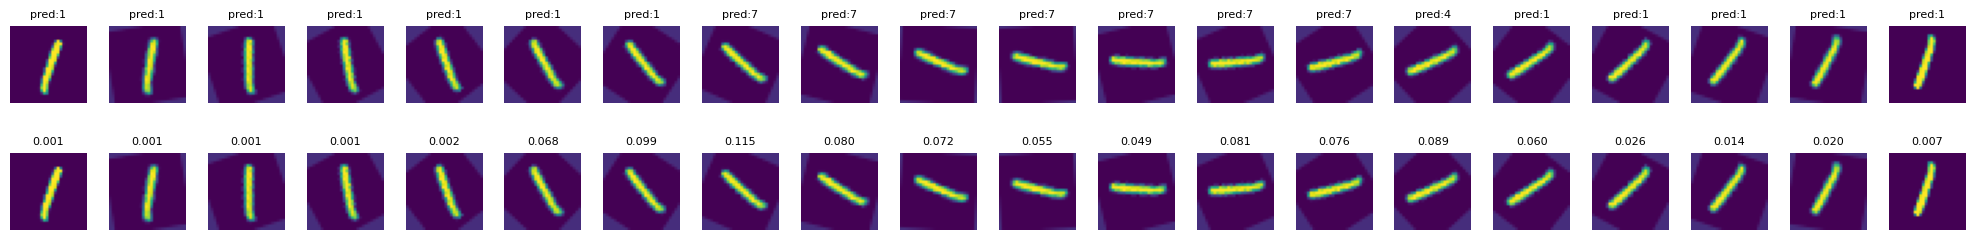

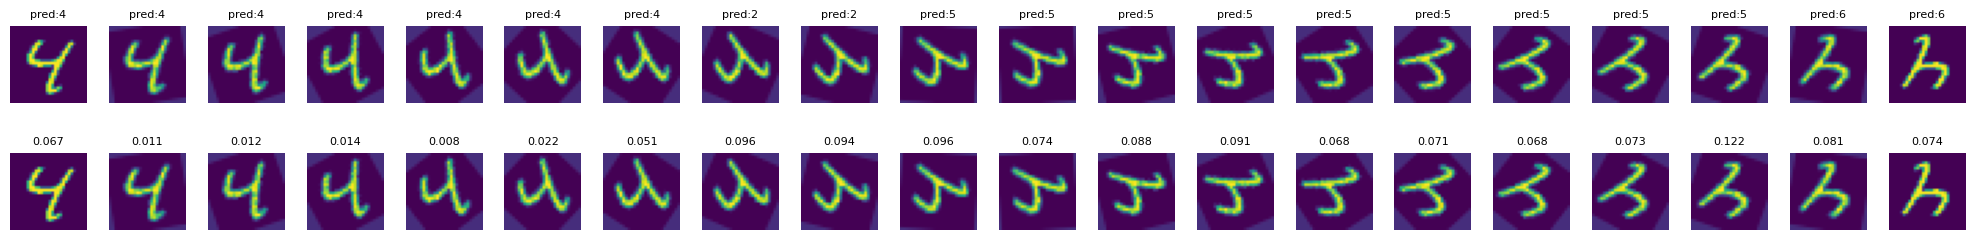

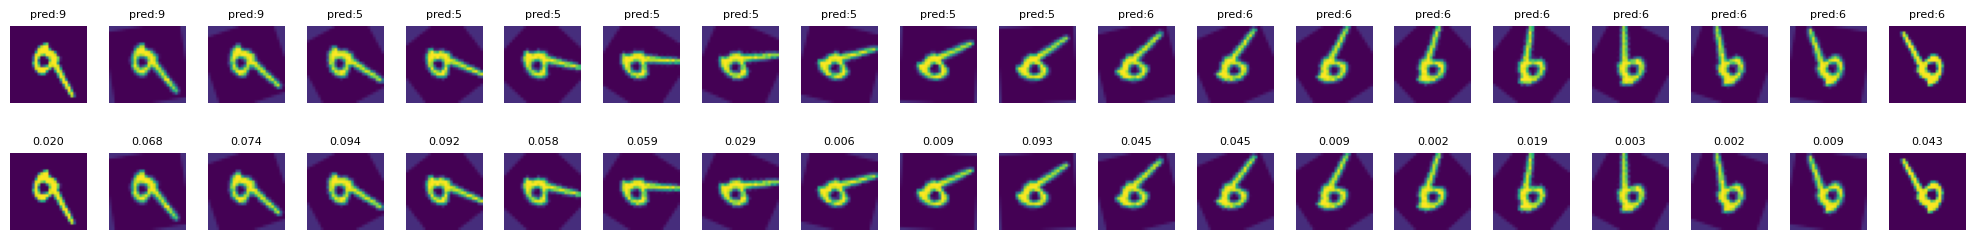

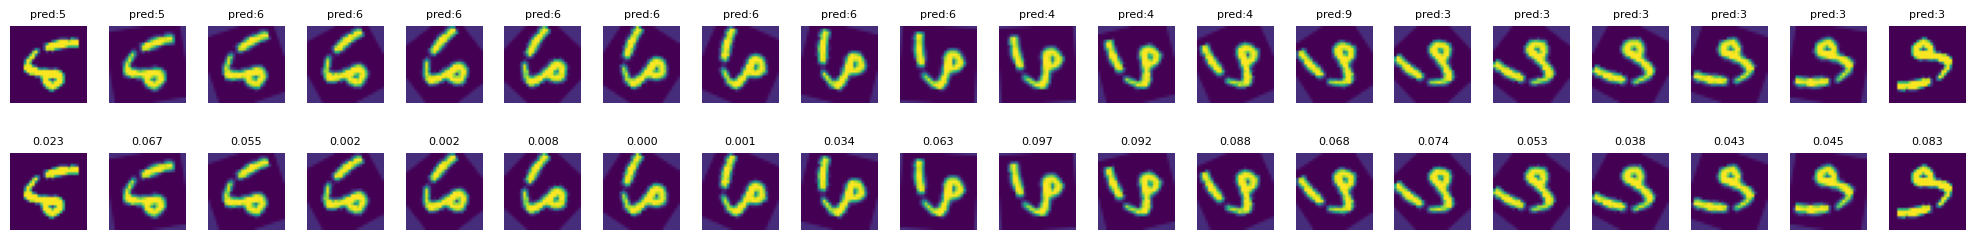

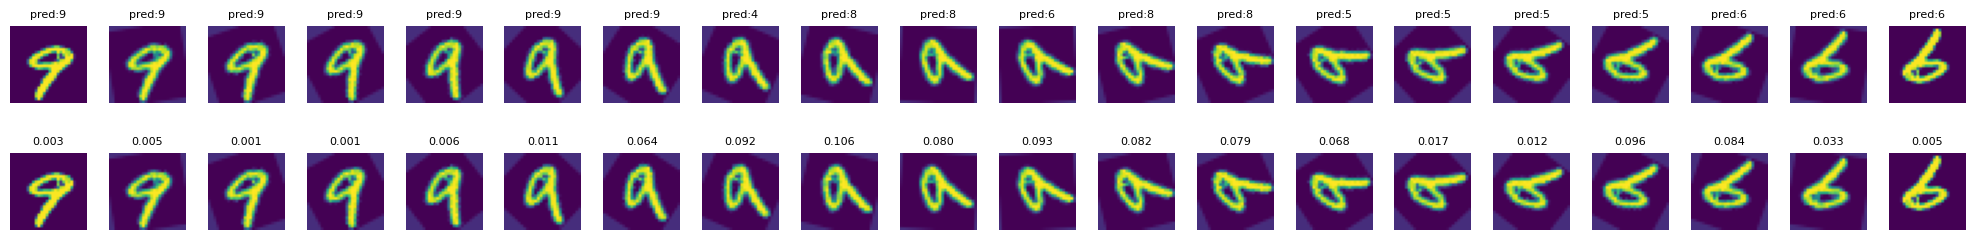

In [ ]:
import torchvision.transforms.functional as TF
def uncertainty_test(model):
    # TODO: Rotate each test image at various angles.
    # Perform MC Dropout at each angle and record prediction confidence and uncertainty.
    # Visualize rotated inputs with their predicted labels and uncertainty levels.
    model.train()
    N = 10
    T = 20
    angles = np.linspace(0, 180, 20)
    data_iter = iter(test_loader)
    images, _ = next(data_iter)
    images = images[:N].to(device)
    angle_rad = np.deg2rad(60)
    R = torch.tensor([[
        [np.cos(angle_rad), -np.sin(angle_rad), 0.0],
        [np.sin(angle_rad),  np.cos(angle_rad), 0.0]
    ]])

    for idx in range(N):
        fig, axes = plt.subplots(2, len(angles), figsize=(len(angles), 3), gridspec_kw={'height_ratios': [1, 1]})
        image = images[idx]

        for j, angle in enumerate(angles):
            rotated = TF.rotate(image.cpu(), angle, interpolation=TF.InterpolationMode.BILINEAR).unsqueeze(0).to(device)
            preds = torch.stack([F.softmax(model(rotated), dim=1) for _ in range(T)])
            mean = preds.mean(dim=0).squeeze()
            std = preds.std(dim=0).squeeze()
            prediction = mean.argmax().item()
            uncertainty = std.mean().item()
            axes[0, j].imshow(rotated.squeeze().cpu(), cmap='viridis')
            axes[0, j].set_title(f'pred:{prediction}', fontsize=8)
            axes[0, j].axis('off')
            axes[1, j].imshow(rotated.squeeze().cpu(), cmap='viridis')
            axes[1, j].set_title(f'{uncertainty:.3f}', fontsize=8)
            axes[1, j].axis('off')

        plt.tight_layout(pad=1.0)
        plt.show()


uncertainty_test(model)


# **Section3:** Bayesian Neural Network MCMC



In this section, we define a class for performing MCMC sampling in a Bayesian neural network (BNN). We specify a model similar to Bayesian linear regression, assuming a Gaussian error model:

$$
y = f(\mathbf{x}, \theta) + e, \quad \quad e \sim \mathcal{N}(0, \tau^2)
\tag{32}
$$

This leads to the same likelihood function as presented earlier. As in standard Bayesian regression, we adopt Gaussian priors for all model parameters ($\theta$), assuming a zero mean and a user-defined variance ($\sigma^2$). For the variance of the noise ($\tau^2$), we assume an inverse Gamma (IG) prior distribution with hyperparameters $\nu_1$ and $\nu_2$.

### Likelihood and Prior Formulation

The likelihood function is derived under the assumption of normally distributed errors, leading to:

$$
p(y \mid \mathbf{x}, \theta, \tau^2) =
\frac{1}{(2 \pi \tau^2)^{S/2}} \exp \left( -\frac{1}{2 \tau^2} \sum_{t=1}^{S} \left( y_t - f(x_t, \theta) \right)^2 \right).
\tag{16}
$$

We construct the prior as follows:
- For $\theta$, we assume a multivariate Gaussian prior:
  
$$
\theta \sim \mathcal{N}(0, \sigma^2).
$$

- For $\tau^2$, we assume an inverse Gamma prior:

$$
\tau^2 \sim IG(\nu_1, \nu_2).
$$

The noise variance $\tau^2$ must be positive, justifying the choice of an inverse Gamma distribution. Since the true value of $\tau^2$ is unknown, it is sampled alongside $\theta$ during the MCMC process.

The combined prior for $\theta$ and $\tau^2$ is:

$$
p(\theta, \tau^2) \propto
\frac{1}{(2\pi\sigma^2)^{M/2}} \exp\left(-\frac{1}{2\sigma^2}\sum_{i=1}^M \theta_i^2\right) \times
(\tau^2)^{-(1+\nu_1)} \exp\left( \frac{-\nu_2}{\tau^2} \right),
\tag{23}
$$

where $M$ is the number of model parameters.

Taking the logarithm for numerical stability, we obtain:

$$
\log\left( p(\theta, \tau^2) \right) = -\frac{M}{2} \log(2\pi\sigma^2) - \frac{1}{2\sigma^2} \sum_{i=1}^M \theta_i^2 - (1 + \nu_1) \log(\tau^2) - \frac{\nu_2}{\tau^2}.
$$

### Implementation Overview

First, we define two key functions that will be integrated into the MCMC class:

- **`prior_val`**: Computes the log prior value.
    - Assumes a Gaussian prior on $\theta$ and an inverse Gamma prior on $\tau^2$.
    - Implements the log-prior function:

$$
\log\left( p(\theta, \tau^2) \right) = -\frac{M}{2}\log(\sigma^2) - \frac{1}{2\sigma^2}\sum_{i=1}^M \theta_i^2 - (1 + \nu_1) \log(\tau^2) - \frac{\nu_2}{\tau^2}.
$$

- **`likelihood_function`**: Computes the log-likelihood of the data given the current weights and biases.
    - The likelihood function is:

$$
p(\mathbf{Y} \mid X, \theta) = \frac{1}{(2\pi \tau^2)^{S/2}} \exp\left( -\frac{1}{2\tau^2} \sum_{t=1}^S \left( y_t - f(\mathbf{x}_t, \theta) \right)^2 \right),
$$

and the log-likelihood becomes:

$$
\log\left( p(\mathbf{Y} \mid X, \theta) \right) = -\frac{S}{2} \log(2\pi\tau^2) - \frac{1}{2\tau^2} \sum_{t=1}^S \left( y_t - f(\mathbf{x}_t, \theta) \right)^2.
$$

These functions form the foundation for constructing the Metropolis-Hastings or other MCMC algorithms for posterior sampling in Bayesian neural networks.



### Imports

In [ ]:
import os
import numpy as np
import pandas as pd
from ipywidgets import interact, fixed, widgets
from tqdm import tqdm
from types import MethodType

np.random.seed(2025)

### Some useful functions

In [ ]:
##############################################
# no need to do any thing,
# However, you can change it if needed
##############################################

def plot_linear_data(x,y,y_modelled=None,y_simulated=None,ci=False,save_fig=False):
    '''
    This function will plot the data in linear format.
    '''
    sns.set_context("talk")
    sns.set_style("ticks",{'axes.grid': True})

    fig = plt.figure(figsize=(7,5))
    ax1 = fig.add_subplot(111)

    sns.scatterplot(
        x=x.squeeze(),y=y.squeeze(),ax=ax1,
        label='Data'
    )

    sns.lineplot(
        x=x.squeeze(),y=np.mean(y_modelled,axis=0),
        ax=ax1,color='red',
        label='Mean Modelled'
    )

    if ci:
        ax1.fill_between(
            x.squeeze(),
            np.percentile(y_simulated,2.5,axis=0),
            np.percentile(y_simulated,97.5,axis=0),
            color='orange',alpha=0.2,
            label='Simulated 95% CI')
    else:
        ax1.fill_between(
            x.squeeze(),
            np.mean(y_simulated,axis=0)-2*np.std(y_simulated,axis=0),
            np.mean(y_simulated,axis=0)+2*np.std(y_simulated,axis=0),
            color='orange',alpha=0.2,
            label='Simulated $\pm 2\sigma$')

    if ci:
        ax1.fill_between(
            x.squeeze(),
            np.percentile(y_modelled,2.5,axis=0),
            np.percentile(y_modelled,97.5,axis=0),
            color='red',alpha=0.2,
            label='Modelled 95% CI')
    else:
        ax1.fill_between(
            x.squeeze(),
            np.mean(y_modelled,axis=0)-2*np.std(y_modelled,axis=0),
            np.mean(y_modelled,axis=0)+2*np.std(y_modelled,axis=0),
            color='red',alpha=0.2,
            label='Modelled $\pm 2\sigma$')

    ax1.set_xlabel('x')
    ax1.set_ylabel('y')
    lgd = plt.legend(loc='center',bbox_to_anchor=(1.3,0.5))
    if save_fig:
        fig.savefig(os.path.join('.', 'figures', 'linear_model_fit.png'),bbox_extra_artists=(lgd,), bbox_inches='tight')
    plt.show()

def plot_y_timeseries(y_obs,y_mod,y_sim=None,dataset_name=None,ci=False,fname=None):
    sns.set_context("talk")
    sns.set_style("ticks",{'axes.grid': True})

    fig = plt.figure(figsize=(9,4))
    ax1 = fig.add_subplot(111)

    x = np.arange(y_obs.shape[0])

    sns.lineplot(
        x=x,y=y_obs.squeeze(),
        ax=ax1,
        label='Observed'
    )
    sns.lineplot(
        x=x,y=np.mean(y_mod,axis=0),
        ax=ax1,color='C3',
        label='Modelled'
    )
    if ci:
        ax1.fill_between(
            x,
            np.percentile(y_mod,2.5,axis=0),
            np.percentile(y_mod,97.5,axis=0),
            color='C3',alpha=0.2,
            label='Modelled 95% CI')
        if not y_sim is None:
            ax1.fill_between(
                x,
                np.percentile(y_sim,2.5,axis=0),
                np.percentile(y_sim,97.5,axis=0),
                color='C1',alpha=0.2,
                label='Simulated 95% CI')
    else:
        ax1.fill_between(
            x,
            np.mean(y_mod,axis=0)-2*np.std(y_mod,axis=0),
            np.mean(y_mod,axis=0)+2*np.std(y_mod,axis=0),
            color='C3',alpha=0.2,
            label='Modelled $\pm 2\sigma$')
        if not y_sim is None:
            ax1.fill_between(
                x,
                np.mean(y_sim,axis=0)-2*np.std(y_sim,axis=0),
                np.mean(y_sim,axis=0)+2*np.std(y_sim,axis=0),
                color='C1',alpha=0.2,
                label='Simulated $\pm 2\sigma$')

    if dataset_name is not None:
        ax1.set_title('{} Data'.format(dataset_name))
    ax1.set_xlabel('Timestep')
    ax1.set_ylabel('Y')
    lgd = plt.legend(loc='center left',bbox_to_anchor=(1.05,0.5))
    if not fname is None:
        plt.savefig(
            fname,
            bbox_extra_artists=(lgd,),
            bbox_inches='tight',
            dpi=300
        )
        plt.close()
    else:
        plt.show()

def plot_ycorr_scatter(y_obs,y_mod,minmax=(0,1),fname=None,dy=False):
    sns.set_context("talk")
    sns.set_style("ticks",{'axes.grid': True})

    fig = plt.figure(figsize=(7,5))
    ax1 = fig.add_subplot(111)

    if not minmax is None:
        ax1.set_xlim(minmax[0],minmax[1])
        ax1.set_ylim(minmax[0],minmax[1])
    else:
        ax1.set_xlim(np.min([y_obs.min(),y_mod.min()]),np.max([y_obs.max(),y_mod.max()]))
        ax1.set_ylim(np.min([y_obs.min(),y_mod.min()]),np.max([y_obs.max(),y_mod.max()]))
    # plot red dashed 1:1 line
    ax1.plot(ax1.get_xlim(),ax1.get_ylim(),'--r')

    sns.scatterplot(
        x=np.mean(y_mod,axis=0).squeeze(),y=y_obs.squeeze(),ax=ax1,
    )

    if not dy:
        ax1.set_xlabel('Y modelled')
        ax1.set_ylabel('Y observed')
    else:
        ax1.set_xlabel('$\Delta$Y modelled')
        ax1.set_ylabel('$\Delta$Y observed')

    if not fname is None:
        plt.savefig(
            fname,
            bbox_inches='tight',
            dpi=300
        )
        plt.close()
    else:
        plt.show()

def boxplot_weights(results, width=20,skip=2):
    '''
    Visualise the weights of the Bayesian Neural Network
    '''
    fig = plt.figure(figsize=(width,width*0.3))
    ax1 = fig.add_subplot(111)

    df = pd.melt(results.drop(columns=['rmse'],errors='ignore'))
    sns.boxplot(data=df,x='variable',y='value', ax=ax1)
    # set labels as invisible to help clutter
    for label in ax1.xaxis.get_ticklabels()[1::skip]:
        label.set_visible(False)
    ax1.set_ylabel('Posterior')
    #         plt.legend(loc='upper right')
    ax1.set_title("Boxplot of Posterior W (weights and biases)", pad=20)
    ax1.set_xlabel('$[w_h][w_o][b_h][b_o][tau]$')
    plt.show()


def histogram_trace(pos_points, true_posterior=None, burn_in=None, fname = None, **kwargs):
    '''
    This function will create a histogram and traceplot of the MCMC results.
    '''
    size = 15

    sns.set(font_scale=1.5)
    sns.set_style("whitegrid")
    fig = plt.figure(figsize=(10, 4))
    if not burn_in is None:
        plot_points = pos_points[burn_in:,...]
    else:
        plot_points = pos_points

    ax1 = fig.add_subplot(111)
    ax1.hist(plot_points,  bins = 20, color='C0', alpha=0.7, label='Sampled posterior')
    x_lims = ax1.get_xlim()
    if not true_posterior is None:
        ax2 = ax1.twinx()
        ax2.grid(False)
        ax2.plot(true_posterior[:,0], true_posterior[:,1], linewidth=2, color='C1', label='True\nDistribution')
        ax2.set_ylim(0, ax2.get_ylim()[1])
        ax2.set_ylabel('Density', fontsize = size)
    ax1.set_xlim(x_lims)
    ax1.set_ylabel('Frequency', fontsize = size, labelpad=10)
    ax1.set_xlabel(kwargs.get('param_name','Parameter value'), fontsize = size, labelpad=10)
    ax1.set_title(kwargs.get('title','Posterior'), fontsize = size, pad=10)
    lgd=plt.legend(bbox_to_anchor=(1.25,0.5),loc='center left')
    fig.tight_layout()
    if not fname is None:
        plt.savefig(fname + '_posterior.pgf',
            bbox_extra_artists=(lgd,),
            bbox_inches='tight',
            dpi=300
        )
        plt.clf()
    else:
        plt.show()

    fig = plt.figure(figsize=(10, 4))
    ax1 = fig.add_subplot(111)
    if not burn_in is None:
        ax1.plot(np.arange(burn_in), pos_points[:burn_in], color='C3',label='Burn-in trace')
        ax1.plot(np.arange(burn_in,pos_points.shape[0]), pos_points[burn_in:], color='C0',label='Posterior trace')
    else:
        ax1.plot(pos_points,label='Posterior trace')
    lgd = plt.legend(loc='center left',bbox_to_anchor=(1.025,0.5))
    plt.title("Parameter trace plot", fontsize = size, pad=10)
    plt.xlabel(' Number of Samples  ', fontsize = size, labelpad=10)
    plt.ylabel(' Parameter value ', fontsize = size, labelpad=10)
    plt.tight_layout()
    if not fname is None:
        plt.savefig(
            fname + '_trace.pgf',
            bbox_extra_artists=(lgd,),
            bbox_inches='tight',
            dpi=300
        )
        plt.clf()
    else:
        plt.show()


## Define a class with the functions and attributes required for a neural network model
First lets define our forward and backward pass functions which form the core of our model. These will be integrated into the NeuralNetwork class and thus contain references to class attributes.

- `forward_pass`: Function to calculate the output of the network from the input data ($x$)
    - for our hidden layer - $h_{output} = g\left(x \cdot w_{h} + \delta_{h} \right)$
    - subsequently for the output layer - $f\left(x\right) = o_{output} = g\left(h_{output} \cdot w_{o} + \delta_{o} \right)$
    - where $g(\cdot)$ is the sigmoid activation function, $w_{h}$ and $w_{o}$ are the weights for the hidden and output layers, and $\delta_{h}$ and $\delta_{o}$ are the biases for the hidden and output layers, respectively.
- `backward_pass`: Function to update the model parameters using Langevin dynamics
    - $\bar{\theta_p} = \theta_p + r \times \nabla E_{y_{\mathcal{A}_{D,T}}}\left[\theta_p\right]$
    - $\nabla E_{y_{\mathcal{A}_{D,T}}}\left[\theta_p\right] = \left(\frac{\delta E}{\delta \theta_1},\dots, \frac{\delta E}{\delta \theta_L} \right)$
    - $E_{y_{\mathcal{A}_{D,T}}}\left[\theta_p\right] = \sum_{t \in \mathcal{A}_{D,T}} \left(y_t - f\left(x_t\right)^{[k]}\right)^2$

    - where $\theta = \left(w_{h},w_{o},\delta_{h},\delta_{o}\right)$ comprises the weights and biases of the NN model

In [ ]:
# NN prediction
def forward_pass(self, X):
    '''
    Take an input X and return the output of the network
    Input:
        - X: (N x num_features) array of input data
    Output:
        - self.l2_output: (N) array of output data f(x) which can be
        compared to observations (Y)
    '''
    # TODO
    self.l1_output = self.sigmoid(np.dot(X, self.wh) + self.bh)
    self.l2_output = self.sigmoid(np.dot(self.l1_output, self.wo) + self.bo)
    return self.l2_output

def backward_pass(self, X, Y):
    '''
    Compute the gradients using a backward pass and undertake Langevin-gradient
    updating of parameters
    Input:
        - X: (N x num_features) array of input data
        - Y: (N) array of target data
    '''
    # TODO
    output_errors = Y - self.l2_output
    output_delta = output_errors * (self.l2_output * (1 - self.l2_output))

    hidden_errors = output_delta.dot(self.wo.T)
    hidden_delta = hidden_errors * (self.l1_output * (1 - self.l1_output))

    grad_wo = self.l1_output.T.dot(output_delta)
    grad_bo = np.sum(output_delta, axis=0, keepdims=True)

    grad_wh = X.T.dot(hidden_delta)
    grad_bh = np.sum(hidden_delta, axis=0, keepdims=True)

    return grad_wh, grad_wo, grad_bh, grad_bo


Below is the NeuralNetwork class, which constitutes our model. The class should contain the following functions:

- `initialise_network`: Function to initialise the weights and biases of the network in both the hidden and output layers
- `evaluate_proposal`: Function to assign a proposed $\theta$ to the weights and biases and forward_pass the input data
- `langevin_gradient`: Function to calculate the Langevin gradient based parameter updates. This uses the gradient computation in the `backward_pass` detailed above
- `sigmoid`: Sigmoid activation function
- `encode`: Return a vector $\theta$ of the current weights and biases of the network
- `decode`: Take a vector $\theta$ and assign it to the weights and biases of the network


In [ ]:
class NeuralNetwork:
    '''
    Neural Network model with a single hidden layer and a single output (y)
    '''
    def __init__(self, layer_sizes,learning_rate=0.01):
        '''
        Initialize the model
        Input:
            - layer_sizes (input, hidden, output): array specifying the number of
            nodes in each layer
            - learning_rate: learning rate for the gradient update
        '''
        self.input_num = layer_sizes[0]
        self.hidden_num = layer_sizes[1]
        self.output_num = layer_sizes[2]
        self.n_params = (self.input_num * self.hidden_num) + (self.hidden_num * self.output_num) + self.hidden_num + self.output_num
        self.lrate = learning_rate
        self.initialise_network()
        self.forward_pass = MethodType(forward_pass, self)
        self.backward_pass = MethodType(backward_pass, self)

    def initialise_network(self):
        '''
        Initialize network structure - weights and biases for the hidden layer
        and output layer
        '''
        # hidden layer
          # TODO
        self.wh = np.random.randn(self.input_num, self.hidden_num) * 0.1
        self.bh = np.random.randn(1, self.hidden_num) * 0.1

        # placeholder for storing the hidden layer values
          # TODO
        self.l1_output = None


        # output layer
          # TODO
        self.wo = np.random.randn(self.hidden_num, self.output_num) * 0.1
        self.bo = np.random.randn(1, self.output_num) * 0.1

        # placeholder for storing the model outputs
          # TODO
        self.l2_output = None

    def evaluate_proposal(self, x_data, theta):
        '''
        A helper function to take the input data and proposed parameter sample
        and return the prediction
        Input:
            data: (N x num_features) array of data
            theta: (w,v,b_h,b_o) vector of parameters with weights and biases
        '''
        # TODO
        self.decode(theta)
        fx = self.forward_pass(x_data)
        prob = 1
        return fx, prob

    def langevin_gradient(self, x_data, y_data, theta, depth):
        '''
        Compute the Langevin gradient based proposal distribution
        Input:
            - x_data: (N x num_features) array of input data
            - y_data: (N) array of target data
            - theta: (w,v,b_h,b_o) vector of proposed parameters.
            - depth: SGD depth
        Output:
            - theta_updated: Updated parameter proposal

        '''
        # TODO
        for _ in range(depth):
            fx = self.forward_pass(x_data)
            grad_wh, grad_wo, grad_bh, grad_bo = self.backward_pass(x_data, y_data)

            self.wh += self.lrate * grad_wh
            self.wo += self.lrate * grad_wo
            self.bh += self.lrate * grad_bh
            self.bo += self.lrate * grad_bo

        theta_updated = self.encode()
        return theta_updated

    # Helper functions
    def sigmoid(self, x):
        '''
        Implentation of the sigmoid function
        '''
        # TODO
        return 1 / (1 + np.exp(-x))

    def encode(self):
        '''
        Encode the model parameters into a vector
        Output:
            - theta: vector of parameters.
        '''
        # TODO
        theta = np.concatenate([self.wh.flatten(), self.wo.flatten(), self.bh.flatten(), self.bo.flatten()])
        return theta

    def decode(self, theta):
        '''
        Decode the model parameters from a vector
        Input:
            - theta: vector of parameters.
        '''
        # TODO
        wh_size = self.input_num * self.hidden_num
        wo_size = self.hidden_num * self.output_num
        bh_size = self.hidden_num
        bo_size = self.output_num

        idx = 0
        self.wh = theta[idx : idx + wh_size].reshape(self.input_num, self.hidden_num)
        idx += wh_size
        self.wo = theta[idx : idx + wo_size].reshape(self.hidden_num, self.output_num)
        idx += wo_size
        self.bh = theta[idx : idx + bh_size].reshape(1, self.hidden_num)
        idx += bh_size
        self.bo = theta[idx : idx + bo_size].reshape(1, self.output_num)

## Define a class for the MCMC sampling
First we will define our `likelihood_function` and `prior_val` functions. These will be integrated into the MCMC class and thus contain references to class attributes.


- `prior_val`: Function to calculate the prior
    - We assume a Gaussian prior distribution
    - $ p(\boldsymbol{\theta}) \propto \frac{1}{(2\pi\sigma^2)^{L/2}}\times
 \exp\Bigg\{-\frac{1}{2\sigma^2}\bigg( \sum_{i=1}^M \theta^2_i \bigg) \Bigg\}
 \times \tau^{-2(1+\nu_1)}\exp\left(\frac{-\nu_2}{\tau^2}\right)$
    - we implement this (using log laws) as:
    - $\log\left(p\left(\theta\right)\right) = -\frac{L}{2}\log\left(\sigma^2\right) - \frac{1}{2\sigma^2}\sum_{i=1}^M \theta^2_i - \left(1 + \nu_1\right)\log\left(\tau^2\right) - \frac{\nu_2}{\tau^2}$
- `likelihood_function`: Function to calculate the likelihood of the data given the current weights and biases of the network
    - Our likelihood is:
    - $p({\mathbf Y}|X,\boldsymbol{\theta}) = \frac{1}{(2\pi \tau ^2)^{S/2}}\times \exp\left( -\frac{1}{2\tau^2}\sum_{t=1}^S \left( y_{t}- f(\mathbf x_t, \theta)\right)^2\right)$
    - $\log{\left(p({\mathbf Y}|X,\boldsymbol{\theta})\right)} = -\frac{1}{2}\log{\left(2\pi\tau^2\right)} - \frac{1}{2\tau^2}\sum_{t=1}^S \left(y_{t}- f(\mathbf x_t, \theta)\right)^2$

In [ ]:
# Define the likelihood function
def likelihood_function(self, theta, tausq, test=False):
    '''
    Calculate the likelihood of the data given the parameters
    Input:
        theta: (M + 1) vector of parameters. The last element of theta consitutes the bias term (giving M + 1 elements)
        tausq: variance of the error term
    Output:
        log_likelihood: log likelihood of the data given the parameters
        model_prediction: prediction of the model given the parameters
        accuracy: accuracy (RMSE) of the model given the parameters
    '''
    # first make a prediction with parameters theta
    # TODO
    if test:
        x_data = self.x_test
        y_data = self.y_test

    else:
        x_data = self.x_data
        y_data = self.y_data

    if y_data.ndim == 1:
        y_data = y_data.reshape(-1, 1)

    self.model.decode(theta)
    model_prediction = self.model.forward_pass(x_data)
    Sh = y_data.shape[0]
    log_likelihood = - (Sh / 2) * np.log(2 * np.pi * tausq) - (1 / (2 * tausq)) * np.sum((y_data - model_prediction)**2)
    model_simulation = model_prediction + np.random.normal(0, np.sqrt(tausq), size=model_prediction.shape)
    accuracy = self.rmse(model_prediction, y_data)

    return [log_likelihood, model_prediction, model_simulation, accuracy]

# Define the prior
def prior(self, sigma_squared, nu_1, nu_2, theta, tausq):
    '''
    Calculate the prior of the parameters
    Input:
        sigma_squared: variance of normal prior for theta
        nu_1: parameter nu_1 of the inverse gamma prior for tau^2
        nu_2: parameter nu_2 of the inverse gamma prior for tau^2
        theta: (M + 1) vector of parameters. The last element of theta consitutes the bias term (giving M + 1 elements)
        tausq: variance of the error term
    Output:
        log_prior: log prior
    '''
    # TODO
    M = len(theta)
    log_prior_theta = - (M / 2) * np.log(2 * np.pi * sigma_squared) - (1 / (2 * sigma_squared)) * np.sum(theta**2)
    log_prior_tausq = -(1 + nu_1) * np.log(tausq) - (nu_2 / tausq)
    log_prior = log_prior_theta + log_prior_tausq

    return log_prior

Next we define the MCMC sampler:

- The acceptance probability is
    - $\alpha = \Bigg(1, \frac{p\left(\theta^p_s|Y\right)q\left(\theta^{[i]}|\theta^{p}\right)}{p\left(\theta^{[i]}|Y\right)q\left(\theta^{p}|\theta^{[i]}\right)}\Bigg)$
- The log posterior ratio:
    - $\frac{p\left(\theta^p_s|Y\right)}{p\left(\theta^{[i]}|Y\right)}$
- where the log posterior is given by the sum of the prior and likelihood:
    - $\log\left(p\left(\theta|Y\right)\right) = \log\left(p\left(\theta\right)\right) + \log\left(p\left(Y|X,\theta\right)\right)$
- In the implementation:
    - `diff_likelihood`: gives the likelihood - $\log\left(p\left(Y|X,\theta\right)\right)$  
    - `diff_prior` gives the prior - $\log\left(p\left(\theta\right)\right)$   

The MCMC sampling algorithm detailed as follows:

<p align="center">
  <img src="alg1.png" alt="Bayesian Neural Network Overview" width="400"/>
</p>


In [ ]:
# MCMC sampler
def sampler(self):
    '''
    Run the sampler for a defined Neural Network model
    '''
    ## define empty arrays to store the sampled posterior values
      # TODO
    pos_theta = np.zeros((self.n_samples, self.theta_size))
    pos_tau = np.zeros((self.n_samples, 1))
    pos_eta = np.zeros((self.n_samples, 1))
    rmse_train = np.zeros(self.n_samples)
    rmse_test = np.zeros(self.n_samples)
    pred_y = np.zeros((self.n_samples, self.y_data.shape[0]))
    sim_y = np.zeros((self.n_samples, self.y_data.shape[0]))
    test_pred_y = np.zeros((self.n_samples, self.y_test.shape[0]))
    test_sim_y = np.zeros((self.n_samples, self.y_test.shape[0]))

    ## Initialisation
      # TODO
    theta = self.model.encode()
    tausq = 1.0
    eta = np.log(tausq)

    [log_likelihood, model_prediction, model_simulation, accuracy] = self.likelihood_function(theta, tausq, test=False)
    log_prior = self.prior(self.sigma_squared, self.nu_1, self.nu_2, theta, tausq)
    log_posterior = log_likelihood + log_prior

    n_accept = 0

    ## Run the MCMC sample for n_samples
    for i in tqdm(np.arange(1,self.n_samples)):
        # TODO
            if self.use_langevin_gradients:
             theta_proposal = self.model.langevin_gradient(self.x_data, self.y_data, theta, self.sgd_depth)
             theta_star = theta_proposal + np.random.normal(0, self.step_theta, self.theta_size)
             eta_star = eta + np.random.normal(0, self.step_eta, 1)

            else:
             theta_star = theta + np.random.normal(0, self.step_theta, self.theta_size)
             eta_star = eta + np.random.normal(0, self.step_eta, 1)

            tausq_star = np.exp(eta_star)

            if tausq_star <= 0:
             pos_theta[i, :] = theta
             pos_tau[i, :] = tausq
             pos_eta[i, :] = eta
             rmse_train[i] = accuracy
             pred_y[i, :] = model_prediction.flatten()
             sim_y[i, :] = model_simulation.flatten()
             [log_likelihood_test, model_prediction_test, model_simulation_test, accuracy_test] = self.likelihood_function(theta, tausq, test=True)
             rmse_test[i] = accuracy_test
             test_pred_y[i, :] = model_prediction_test.flatten()
             test_sim_y[i, :] = model_simulation_test.flatten()
             continue

            [log_likelihood_star, model_prediction_star, model_simulation_star, accuracy_star] = self.likelihood_function(theta_star, tausq_star, test=False)
            log_prior_star = self.prior(self.sigma_squared, self.nu_1, self.nu_2, theta_star, tausq_star)
            log_posterior_star = log_likelihood_star + log_prior_star
            log_alpha = log_posterior_star - log_posterior

            if log_alpha >= np.log(np.random.rand()):
             theta = theta_star
             tausq = tausq_star
             eta = eta_star
             log_posterior = log_posterior_star
             model_prediction = model_prediction_star
             model_simulation = model_simulation_star
             accuracy = accuracy_star
             n_accept += 1

            pos_theta[i, :] = theta
            pos_tau[i, :] = tausq
            pos_eta[i, :] = eta
            rmse_train[i] = accuracy
            pred_y[i, :] = model_prediction.flatten()
            sim_y[i, :] = model_simulation.flatten()

            [log_likelihood_test, model_prediction_test, model_simulation_test, accuracy_test] = self.likelihood_function(theta, tausq, test=True)
            rmse_test[i] = accuracy_test
            test_pred_y[i, :] = model_prediction_test.flatten()
            test_sim_y[i, :] = model_simulation_test.flatten()

    # print the % of times the proposal was accepted
    accept_ratio = (n_accept / self.n_samples) * 100
    print('{:.3}% were acepted'.format(accept_ratio))

    # store the posterior of theta and tau, as well as the RMSE of these samples
    self.pos_theta = pos_theta[self.n_burnin:, ]
    self.pos_tau = pos_tau[self.n_burnin:, ]
    self.pos_eta = pos_eta[self.n_burnin:, ]

    # Create a pandas dataframe to store the posterior samples of theta and tau, the
    # associated RMSE
    results_dict = {'w{}'.format(_): self.pos_theta[:, _].squeeze() for _ in range(self.theta_size-2)}
    results_dict['b0'] = self.pos_theta[:, self.theta_size-2].squeeze()
    results_dict['b1'] = self.pos_theta[:, self.theta_size-1].squeeze()
    results_dict['tau'] = self.pos_tau.squeeze()

    # return the predictions
    pred_dict = {}
    pred_dict['train_pred'] = pred_y[self.n_burnin:,:]
    pred_dict['train_sim'] = sim_y[self.n_burnin:,:]
    pred_dict['test_pred'] = test_pred_y[self.n_burnin:,:]
    pred_dict['test_sim'] = test_sim_y[self.n_burnin:,:]

    results_df = pd.DataFrame.from_dict(results_dict)

    return results_df, pred_dict

Now let's creat the MCMC class, which runs the sampling of our model:


In [ ]:
class MCMC:
    def __init__(self, model, n_samples, n_burnin, x_data, y_data, x_test, y_test):
        self.n_samples = n_samples # number of MCMC samples
        self.n_burnin = n_burnin # number of burn-in samples
        self.x_data = x_data # (N x num_features)
        self.y_data = y_data # (N x 1)
        self.x_test = x_test # (Nt x num_features)
        self.y_test = y_test # (Nt x 1)

        # MCMC sampler hyperparameters - defines how much variation you need in changes to theta, tau
        self.step_theta = 0.025;
        self.step_eta = 0.2; # note eta is used as tau in the sampler to consider log scale.
        # Hyperpriors
        self.sigma_squared = 25
        self.nu_1 = 0
        self.nu_2 = 0

        # initisalise the linear model class
        self.model = model
        self.use_langevin_gradients = True
        self.sgd_depth = 1
        self.l_prob = 0.5 # likelihood prob
        self.theta_size = self.model.n_params # weights for each feature and a bias term

        # store output
        self.pos_theta = None
        self.pos_tau = None
        self.pos_eta = None
        self.rmse_data = None

        # functions defined above
        self.likelihood_function = MethodType(likelihood_function, self)
        self.prior = MethodType(prior, self)
        self.sampler = MethodType(sampler, self)

    def rmse(self, predictions, targets):
        '''
        Additional error metric - root mean square error
        '''
        # TODO
        return np.sqrt(np.mean((predictions - targets)**2))

## Load the data


In [ ]:
# load the data
from google.colab import files
uploaded = files.upload()
name        = "Sunspot" # "Sunspot", "Abalone"
train_data   = np.loadtxt("train.txt".format(name))
test_data    = np.loadtxt("test.txt".format(name))

print('Training data shape: {}'.format(train_data.shape))
print('Test data shape: {}'.format(test_data.shape))

Saving test.txt to test.txt
Saving train.txt to train.txt
Training data shape: (298, 5)
Test data shape: (198, 5)


## Sample using MCMC

- Create the MCMC loop and sample the posterior distribution

In [ ]:
## MCMC Settings and Setup
n_samples       = 5000 # number of samples to draw from the posterior
burn_in         = int(n_samples* 0.5) # number of samples to discard before recording draws from the posterior
hidden          = 5 # TODO
learning_rate   = 0.01 # TODO

x_data = train_data[:, :-1]
y_data = train_data[:, -1].reshape(-1, 1)
x_test = test_data[:, :-1]
y_test = test_data[:, -1].reshape(-1, 1)

layer_sizes = [x_data.shape[1], hidden, y_data.shape[1]] # TODO

# Initialise the MCMC class
nn_model = NeuralNetwork(layer_sizes, learning_rate) # TODO
mcmc = MCMC(nn_model,n_samples, burn_in, x_data, y_data, x_test, y_test)

# Run the sampler
results, pred = mcmc.sampler() # TODO

100%|██████████| 4999/4999 [00:02<00:00, 2126.76it/s]

14.8% were acepted


In [ ]:
# gather the predicitons into useful variables
pred_y = pred['train_pred']
sim_y = pred['train_sim']
pred_y_test = pred['test_pred']
sim_y_test = pred['test_sim']

## Analyse the results
Plot the data with the mean linear fit and some uncertainty.

Plot the posterior distribution and trace for each parameter using ipywidgets.

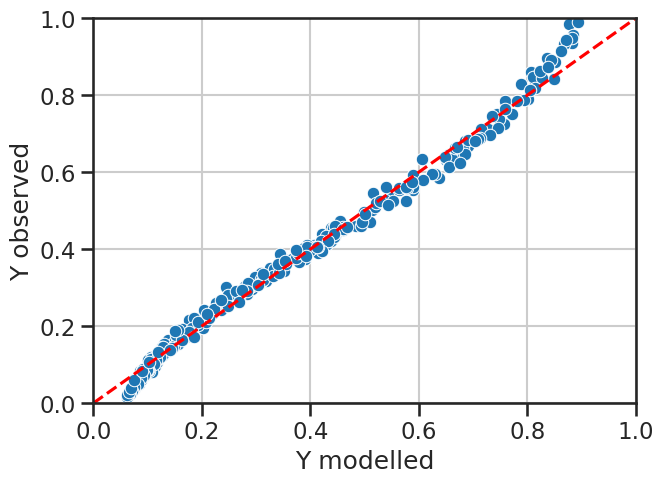

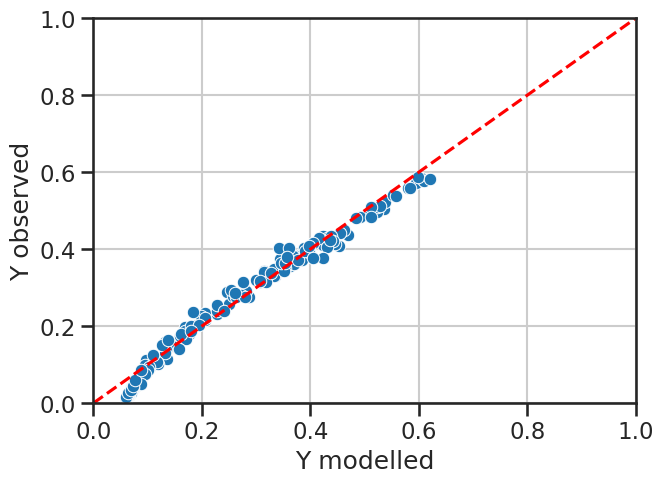

In [ ]:
# plot the data with the model predictions from posterior draws
plot_minmax = (0,1)
plot_ycorr_scatter(
    y_data,
    pred_y,
    minmax=plot_minmax
)
plot_ycorr_scatter(
    y_test,
    pred_y_test,
    minmax=plot_minmax
)

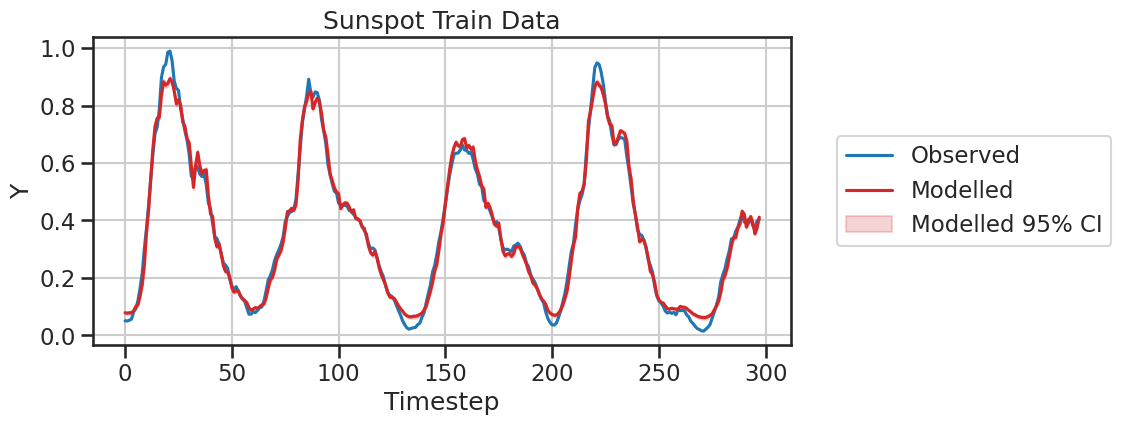

In [ ]:
plot_y_timeseries(
    y_data,
    pred_y,
    dataset_name=name + ' Train',
    ci=True
)

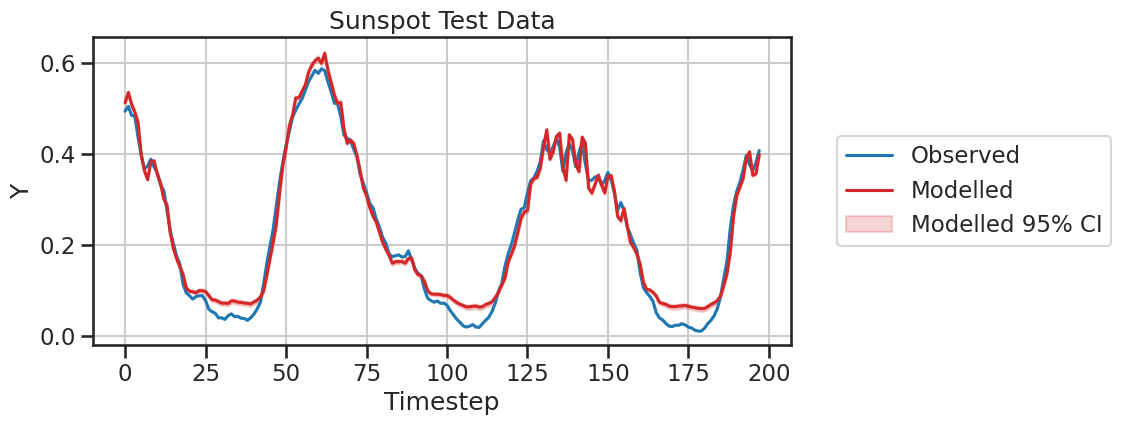

In [ ]:
plot_y_timeseries(
    y_test,
    pred_y_test,
    dataset_name=name + ' Test',
    ci=True
)

In [ ]:
# Print the train/test RMSE
print('RMSE: mean (std)')
train_RMSE = np.array([mcmc.rmse(pred_y[i, :], y_data) for i in range(pred_y.shape[0])]) # TODO
test_RMSE = np.array([mcmc.rmse(pred_y_test[i, :], y_test) for i in range(pred_y_test.shape[0])]) # TODO
print('Train RMSE: {:.5f} ({:.5f})'.format(train_RMSE.mean(),train_RMSE.std()))
print('Test RMSE: {:.5f} ({:.5f})'.format(test_RMSE.mean(),test_RMSE.std()))

RMSE: mean (std)
Train RMSE: 0.35692 (0.00102)
Test RMSE: 0.23541 (0.00066)


In [ ]:
def plot_hist(results, param_name):
    # results = results_rmse
    posterior_mean = results[param_name].mean()
    print('{:.3f} mean value of posterior'.format(posterior_mean))
    histogram_trace(results[param_name].values)

# use ipywidgets to get a "gui" dropdown to view all the parameters
interact(
    plot_hist,
    results=fixed(results),
    param_name=widgets.Dropdown(
        options=results.columns,
        value='w0',
        description='Parameter:',
    )
)

interactive(children=(Dropdown(description='Parameter:', options=('w0', 'w1', 'w2', 'w3', 'w4', 'w5', 'w6', 'w…

<function __main__.plot_hist(results, param_name)>

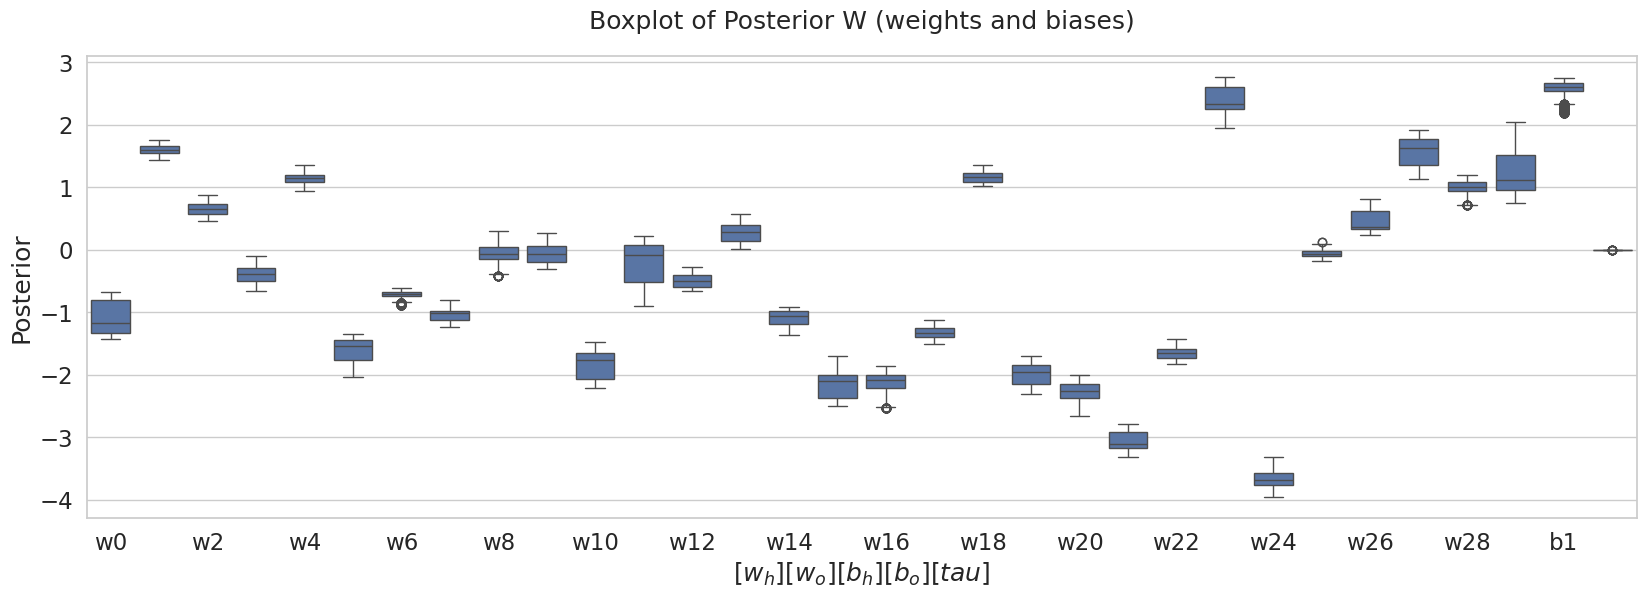

In [ ]:
# Visualise all the network weights
boxplot_weights(results,width=20)

Finally, provide intuitive explanations and justifications for the results you obtained: <span style="color:red">

In this section, we implemented the Metropolis-Hastings algorithm to draw samples from the posterior distribution. After running the chain for a sufficient number of iterations, the generated samples closely matched the true posterior, indicating that the algorithm performed as expected and provided a reliable representation of the distribution.

To improve the quality of the samples, we applied a burn-in period to discard the initial steps, which might have been overly influenced by the starting values. Additionally, thinning was employed to reduce redundancy among consecutive samples, resulting in a cleaner and more informative set of points for analysis.

The core idea of the algorithm is straightforward: it explores the parameter space by taking random steps, usually accepting moves that increase the likelihood, but occasionally accepting less likely moves to ensure thorough exploration. This approach allows MCMC to capture the full distribution of the parameters, which is particularly valuable for complex or multimodal distributions, providing a better understanding of parameter uncertainty than relying on a single point estimate.
</span>**

# **Section4:** Hamiltonain Monte Carlo


This section guides you through implementing a Hamiltonian Monte Carlo (HMC) sampler for a Bayesian Neural Network (BNN) applied to a classification task on a synthetic dataset. The goal is to understand Bayesian inference in neural networks and how HMC can be used to sample from the posterior distribution of model parameters.

## Table of Contents
1. [Introduction to Bayesian Neural Networks](#introduction-to-bayesian-neural-networks)
2. [Hamiltonian Monte Carlo: Theory](#hamiltonian-monte-carlo-theory)
3. [Dataset Preparation](#dataset-preparation)
4. [Bayesian Neural Network Implementation](#bayesian-neural-network-implementation)
5. [HMC Sampler Implementation](#hmc-sampler-implementation)
6. [Training and Sampling](#training-and-sampling)
7. [Evaluation and Visualization](#evaluation-and-visualization)
8. [NUTS with Pyro](#nuts-with-pyro)


## Bayesian Neural Networks Review

Bayesian Neural Networks (BNNs) extend traditional neural networks by placing probability distributions over the model parameters (weights and biases) instead of using fixed point estimates. This allows BNNs to quantify uncertainty in predictions, which is crucial for applications requiring robustness, such as medical diagnosis or autonomous systems.

In a BNN, the goal is to compute the posterior distribution over the parameters $\theta$ given the data $\mathcal{D} = \{(\mathbf{x}_i, y_i)\}_{i=1}^N$:

$$ p(\theta | \mathcal{D}) = \frac{p(\mathcal{D} | \theta) p(\theta)}{p(\mathcal{D})} $$

where:
- $ p(\mathcal{D} | \theta) $: The likelihood of the data given the parameters.
- $ p(\theta) $: The prior distribution over the parameters.
- $ p(\mathcal{D}) $: The evidence, a normalizing constant.

Since the evidence $ p(\mathcal{D}) $ is often intractable, we use sampling methods like Hamiltonian Monte Carlo to approximate the posterior.

## Hamiltonian Monte Carlo
Hamiltonian Monte Carlo (HMC) is a Markov Chain Monte Carlo (MCMC) method that uses concepts from physics to efficiently sample from high-dimensional probability distributions, such as the posterior of a BNN. HMC leverages Hamiltonian dynamics to propose new states, making it more efficient than random-walk MCMC methods.

## Hamiltonian Dynamics

HMC treats the parameters $\theta$ as the position of a particle in a physical system and introduces auxiliary momentum variables $\mathbf{p}$. The joint distribution over position and momentum is defined by the Hamiltonian:
$$ H(\theta, \mathbf{p}) = U(\theta) + K(\mathbf{p}) $$
where:

- $ U(\theta) = -\log(p(\theta | \mathcal{D})) $: The potential energy, proportional to the negative log posterior.
- $ K(\mathbf{p}) = \frac{1}{2} \mathbf{p}^T \mathbf{M}^{-1} \mathbf{p} $: The kinetic energy, typically with a mass matrix $\mathbf{M} = I$ (identity matrix).

The dynamics are governed by Hamilton's equations:

$$ \frac{d\theta_i}{dt} = \frac{\partial H}{\partial p_i} = \mathbf{M}^{-1} \mathbf{p} $$$$ \frac{d p_i}{dt} = -\frac{\partial H}{\partial \theta_i} = -\frac{\partial U}{\partial \theta_i} $$

These equations are simulated using a numerical integrator, such as the leapfrog method, to propose new states.
HMC Algorithm

1. Initialize: Start with initial parameters $\theta_0$.
2. Sample Momentum: Draw $\mathbf{p} \sim \mathcal{N}(0, \mathbf{M})$.
3. Simulate Dynamics: Use leapfrog integration to simulate Hamiltonian dynamics for $L$ steps with step size $\epsilon$.
4. Metropolis Acceptance: Accept the proposed state $(\theta', \mathbf{p}')$ with probability:

$$ \alpha = \min\left(1, \exp \left(-H(\theta', \mathbf{p}') + H(\theta, \mathbf{p})\right)\right) $$

5. Repeat: Collect samples to approximate the posterior.

HMC is particularly effective for BNNs because it can explore high-dimensional parameter spaces efficiently, avoiding the slow exploration of random-walk methods.

## Setup & Dataset Preparation

We use the `make_moons` dataset from scikit-learn, a synthetic binary classification dataset with two crescent-shaped classes. The data is standardized and split into training and test sets.

In [1]:
#@title Imports
import torch
import torch.nn as nn
import torch.nn.functional as F
from torch.distributions.normal import Normal
import matplotlib.pyplot as plt
import numpy as np
from sklearn.datasets import make_moons
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.decomposition import PCA
import math
import random


In [2]:
#@title Seed

SEED : int = 42

def set_seed(seed=42):
    """
    Set random seeds for reproducibility across PyTorch, NumPy, and Python's random module.

    Args:
        seed (int): The seed value to set for all random number generators.
    """
    # Set Python's random seed
    random.seed(seed)

    # Set NumPy's random seed (used by sklearn and matplotlib)
    np.random.seed(seed)

    # Set PyTorch's random seed for CPU and GPU
    torch.manual_seed(seed)
    torch.cuda.manual_seed(seed)
    torch.cuda.manual_seed_all(seed)  # For multi-GPU setups

    # Ensure deterministic behavior in PyTorch
    torch.backends.cudnn.deterministic = True
    torch.backends.cudnn.benchmark = False

# Set the seed before any random operations
set_seed(SEED)

In [3]:
#@title Dataset

# Generate moon-shaped dataset
X, y = make_moons(n_samples=1000, noise=0.2, random_state=42)

# Standardize features
scaler = StandardScaler()
X = scaler.fit_transform(X)

# Split into train/test
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=SEED)

# Convert to torch tensors
X_train = torch.tensor(X_train, dtype=torch.float32)
X_test = torch.tensor(X_test, dtype=torch.float32)
y_train = torch.tensor(y_train, dtype=torch.long)
y_test = torch.tensor(y_test, dtype=torch.long)

### Explanation
- **Dataset**: The `make_moons` dataset creates 1000 samples with two features and binary labels.
- **Standardization**: Features are standardized to have zero mean and unit variance, which is crucial for neural network training.
- **Train-Test Split**: 80% of the data is used for training, and 20% for testing.
- **Visualization**: The `plot_data` function visualizes the dataset, showing the two crescent-shaped classes.

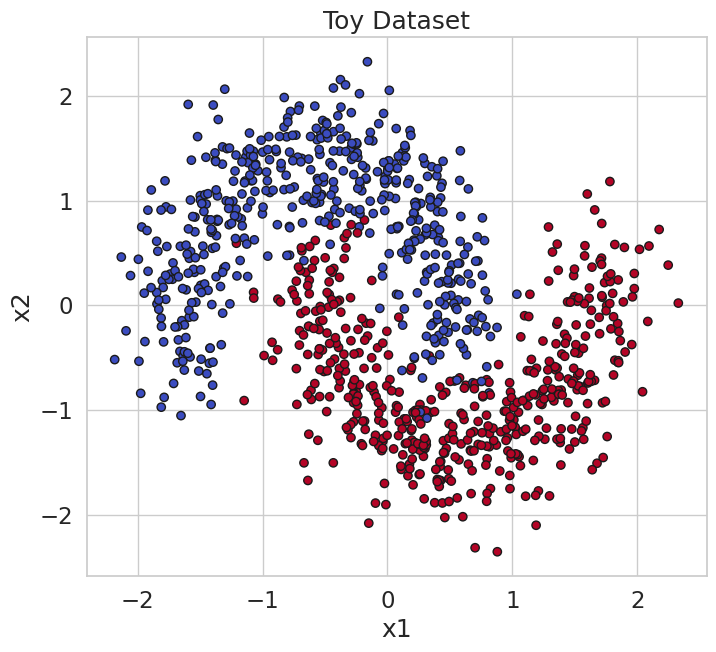

In [ ]:
def plot_data(X, y, title="Toy Dataset"):
    """Plot the 2D dataset with class labels."""
    plt.scatter(X[:, 0], X[:, 1], c=y, cmap='coolwarm', edgecolor='k')
    plt.xlabel("x1")
    plt.ylabel("x2")
    plt.title(title)
    plt.show()

plot_data(X, y)

## Modules

### BNN Module

The BNN is implemented as a PyTorch module with three hidden layers. Unlike traditional neural networks, **the BNN takes parameters as a flattened vector**, allowing us to sample parameters using HMC.

- **Architecture**: The BNN has three hidden layers with ReLU activations and an output layer for binary classification.
- **Parameter Vector**: Parameters are stored as a flattened vector, which is unpacked into weights and biases for each layer.
- **Forward Pass**: The forward method takes input data and a parameter vector, producing logits for classification.


In [4]:
class BayesianNN(nn.Module):
    """Bayesian Neural Network for binary classification."""
    def __init__(self, input_dim=2, hidden_dim1=64, hidden_dim2=64,
                 hidden_dim3=32, output_dim=2):
        super().__init__()
        self.input_dim = input_dim
        self.hidden_dim1 = hidden_dim1
        self.hidden_dim2 = hidden_dim2
        self.hidden_dim3 = hidden_dim3
        self.output_dim = output_dim

        # total parameter size
        self.param_size = (
            input_dim * hidden_dim1 + hidden_dim1 + hidden_dim1 * hidden_dim2 + hidden_dim2 +
            hidden_dim2 * hidden_dim3 + hidden_dim3 + hidden_dim3 * output_dim + output_dim
            # TODO
        )

    def unpack_params(self, params):
        """Unpack flattened parameter vector into weights and biases."""
        offset = 0
        w1 = params[offset : offset + self.input_dim * self.hidden_dim1].reshape(self.input_dim, self.hidden_dim1)
        offset += self.input_dim * self.hidden_dim1
        b1 = params[offset : offset + self.hidden_dim1]
        offset += self.hidden_dim1

        w2 = params[offset : offset + self.hidden_dim1 * self.hidden_dim2].reshape(self.hidden_dim1, self.hidden_dim2)
        offset += self.hidden_dim1 * self.hidden_dim2
        b2 = params[offset : offset + self.hidden_dim2]
        offset += self.hidden_dim2

        w3 = params[offset : offset + self.hidden_dim2 * self.hidden_dim3].reshape(self.hidden_dim2, self.hidden_dim3)
        offset += self.hidden_dim2 * self.hidden_dim3
        b3 = params[offset : offset + self.hidden_dim3]
        offset += self.hidden_dim3

        w4 = params[offset : offset + self.hidden_dim3 * self.output_dim].reshape(self.hidden_dim3, self.output_dim)
        offset += self.hidden_dim3 * self.output_dim
        b4 = params[offset : offset + self.output_dim]

        return w1, b1, w2, b2, w3, b3, w4, b4

    def forward(self, x, params):
        """Forward pass through the network with given parameters."""
        w1, b1, w2, b2, w3, b3, w4, b4 = self.unpack_params(params)
        x = F.relu(x @ w1 + b1)
        x = F.relu(x @ w2 + b2)
        x = F.relu(x @ w3 + b3)
        x = x @ w4 + b4
        return x


### Standard HMC

Now we implement the HMC sampler, which samples from the posterior distribution of the BNN's parameters.

- **Initialization**: The sampler takes the BNN model, training data, step size ($\epsilon$), number of leapfrog steps ($L$), and prior standard deviation.
- **Log Likelihood**: Computes the negative cross-entropy loss for the training data.
- **Log Prior**: Assumes a Gaussian prior over parameters.
- **Potential Energy**: Negative log posterior, combining likelihood and prior.
- **Gradient**: Uses PyTorch's autograd to compute the gradient of the potential energy.
- **Leapfrog**: Implements the leapfrog integrator for Hamiltonian dynamics.
- **Sampling**: Runs HMC for a specified number of samples, optionally include a burn-in period to stabilize the chain.



In [5]:
class HMCSampler():
    """Hamiltonian Monte Carlo sampler for Bayesian Neural Networks."""
    def __init__(self, model, X_train, y_train, epsilon=0.01, L=10, prior_std=1.0, M=None):
        self.model = model
        self.X_train = X_train
        self.y_train = y_train
        self.epsilon = epsilon
        self.L = L
        self.prior_std = prior_std
        self.prior = Normal(0, prior_std)
        self.p_dim = self.model.param_size

        if M is None:
            self.M = torch.eye(self.p_dim)
        else:
            self.M = M

        self.M_inv = torch.inverse(self.M)

    def log_likelihood(self, params):
        """Log-likelihood: log p(y | x, theta) is approximately CrossEntropyLoss"""
        logits = self.model(self.X_train, params)
        logits = torch.clamp(logits, min=-30.0, max=30.0)
        return -F.cross_entropy(logits, self.y_train, reduction='sum')

    def log_prior(self, params):
        """Log-prior: assume independent Gaussian for each theta_i"""
        return self.prior.log_prob(params).sum()

    def potential_energy(self, params):
        """Potential energy = -[log-likelihood + log-prior]"""
        log_lik = self.log_likelihood(params)
        log_pri = self.log_prior(params)
        U = - (log_lik + log_pri)
        if not torch.isfinite(U):
            U = torch.tensor(float('inf'))
        return U

    def grad_potential_energy(self, params):
        """Compute gradient U(theta) using autograd"""
        params = params.detach().clone().requires_grad_(True)
        U = self.potential_energy(params)
        U.backward()
        grad = params.grad
        if grad is None or not torch.isfinite(grad).all():
            grad = torch.zeros_like(params)
        return grad

    def kinetic_energy(self, momentum):
        """Kinetic energy = 0.5 * p^T M^(-1) p"""
        return 0.5 * momentum @ self.M_inv @ momentum

    def grad_kinetic_energy(self, momentum, auto=False):
        """gradK(p) = M^-1 p"""
        return self.M_inv @ momentum

    def hamiltonian(self, params, momentum):
        """H = U + K"""
        return self.potential_energy(params) + self.kinetic_energy(momentum)

    def leapfrog(self, params, momentum):
        """Simulate Hamiltonian dynamics using leapfrog integrator."""
        params = params.clone().detach()
        momentum = momentum.clone().detach()

        grad_U = self.grad_potential_energy(params)
        momentum -= 0.5 * self.epsilon * grad_U

        for i in range(self.L):
            params += self.epsilon * self.M_inv @ momentum
            grad_U = self.grad_potential_energy(params)
            if i != self.L - 1:
                momentum -= self.epsilon * grad_U

        momentum -= 0.5 * self.epsilon * grad_U

        return params.detach(), momentum.detach()

    def sample(self, num_samples, burn_in=300):
        """Sample from posterior using HMC with MH correction."""
        current_params = torch.randn(self.p_dim) * self.prior_std
        samples = []
        acceptance_rate = 0

        for i in range(num_samples + burn_in):
            momentum = torch.randn(self.p_dim)

            proposed_params, proposed_momentum = self.leapfrog(current_params, momentum)

            # Compute Hamiltonians
            current_H = self.hamiltonian(current_params, momentum)
            proposed_H = self.hamiltonian(proposed_params, proposed_momentum)

            # Metropolis-Hastings acceptance
            acceptance_prob = torch.exp(current_H - proposed_H).clamp(max=1.0)
            if torch.rand(1) < acceptance_prob:
                current_params = proposed_params
                acceptance_rate += 1

            if i >= burn_in:
                samples.append(current_params.clone())

            if (i + 1) % 100 == 0:
                rate = acceptance_rate / (i + 1)
                print(f"Iteration {i+1}/{num_samples+burn_in}, Acceptance rate: {rate:.3f}")

        return torch.stack(samples)

## Training and Sampling

To train the BNN, we use the HMC sampler to generate samples from the posterior distribution.

- **Model Initialization**: Creates a BNN with the default architecture.
- **Sampling**: Generates 1000 samples after a burn-in of 1000 iterations to ensure convergence.
- **Tuning Parameters**: Students should experiment with $\epsilon$ and $L$ to achieve a good acceptance rate (typically 60-80%).


In [7]:
bnn = BayesianNN()
sampler = HMCSampler(bnn, X_train, y_train, epsilon=0.01, L=10, prior_std=1.0)

# Sample from posterior
num_samples = 1000
samples = sampler.sample(num_samples=num_samples, burn_in=300)

Iteration 100/1300, Acceptance rate: 0.080
Iteration 200/1300, Acceptance rate: 0.040
Iteration 300/1300, Acceptance rate: 0.027
Iteration 400/1300, Acceptance rate: 0.020
Iteration 500/1300, Acceptance rate: 0.016
Iteration 600/1300, Acceptance rate: 0.017
Iteration 700/1300, Acceptance rate: 0.021
Iteration 800/1300, Acceptance rate: 0.020
Iteration 900/1300, Acceptance rate: 0.019
Iteration 1000/1300, Acceptance rate: 0.018
Iteration 1100/1300, Acceptance rate: 0.016
Iteration 1200/1300, Acceptance rate: 0.015
Iteration 1300/1300, Acceptance rate: 0.014


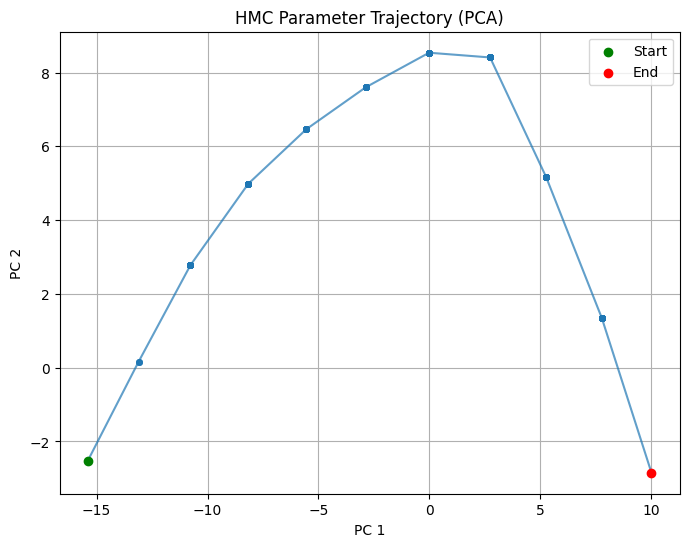

In [8]:
def visualize_hmc_samples(samples, title = "HMC Parameter Trajectory (PCA)"):
    """
    Visualizes how parameter samples evolve during HMC sampling using PCA.

    Args:
        samples (Tensor): [num_samples, param_dim]
    """
    if samples.dim() > 2:
        samples = samples.view(samples.size(0), -1)  # Flatten if needed

    # Apply PCA to reduce to 2D
    pca = PCA(n_components=2)
    reduced = pca.fit_transform(samples.numpy())

    # Plot trajectory
    plt.figure(figsize=(8, 6))
    plt.plot(reduced[:, 0], reduced[:, 1], '-o', markersize=4, alpha=0.7)
    plt.scatter(reduced[0, 0], reduced[0, 1], c='green', label='Start', zorder=5)
    plt.scatter(reduced[-1, 0], reduced[-1, 1], c='red', label='End', zorder=5)
    plt.title(title)
    plt.xlabel("PC 1")
    plt.ylabel("PC 2")
    plt.legend()
    plt.grid(True)
    plt.show()

visualize_hmc_samples(samples)

## Evaluation and Visualization

To evaluate the BNN, we compute the predictive distribution by averaging predictions over the posterior samples.

- **Predictive Distribution**: Averages softmax probabilities over posterior samples to get robust predictions.
- **Decision Boundary**: Visualizes the probability of class 1 across a grid, showing the BNN's decision boundary and uncertainty.
- **Accuracy**: Computes classification accuracy on the test set.

Test Accuracy: 0.675


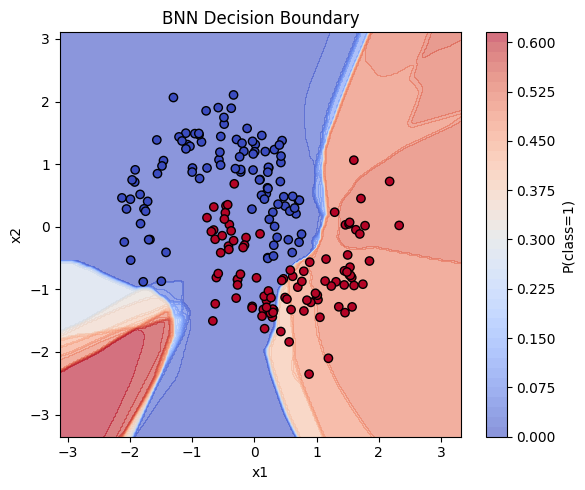

In [9]:
def predict_proba(X, model, samples):
    """Compute predictive probabilities by averaging over posterior samples."""
    # TODO
    model.eval()
    probs = []
    with torch.no_grad():
        for params in samples:
            logits = model(X, params)
            prob = F.softmax(logits, dim=1)
            probs.append(prob)
    return torch.stack(probs).mean(dim=0)

def plot_decision_boundary(X, y, model, samples):
    """Plot decision boundary using posterior samples."""
    # TODO
    # Suggestion: use contourf with cmap 'coolwarm', alpha 0.5 and 50 levels to get similar output.
    #             also use scatter with edgecolor = 'k' and cmap 'coolwarm'.
    x_min, x_max = X[:, 0].min() - 1, X[:, 0].max() + 1
    y_min, y_max = X[:, 1].min() - 1, X[:, 1].max() + 1
    xx, yy = torch.meshgrid(
        torch.linspace(x_min, x_max, 200),
        torch.linspace(y_min, y_max, 200),
        indexing='ij'  # avoid warning
    )
    grid = torch.stack([xx.ravel(), yy.ravel()], dim=1)

    probs = predict_proba(grid, model, samples)
    prob_class1 = probs[:, 1].reshape(xx.shape).numpy()

    plt.figure(figsize=(6, 5))
    contour = plt.contourf(xx.numpy(), yy.numpy(), prob_class1,
                           levels=50, cmap='coolwarm', alpha=0.6)
    plt.colorbar(contour, label="P(class=1)")
    plt.scatter(X[:, 0], X[:, 1], c=y, cmap='coolwarm', edgecolor='k')
    plt.xlabel("x1")
    plt.ylabel("x2")
    plt.title("BNN Decision Boundary")
    plt.tight_layout()
    plt.show()


# Evaluate and visualize
probs = predict_proba(X_test, bnn, samples)
predictions = probs.argmax(dim=1)
accuracy = (predictions == y_test).float().mean().item() # TODO
print(f"Test Accuracy: {accuracy:.3f}")
plot_decision_boundary(X_test, y_test, bnn, samples)

## Conclusion and Further Exploration

This notebook provides a complete implementation of a BNN with HMC sampling. Students are encouraged to:
- Experiment with different network architectures (e.g., varying hidden layer sizes).
- Adjust HMC parameters ($\epsilon$, $L$) and analyze their impact on sampling efficiency.
- Explore other datasets or priors.
- Investigate the effect of the number of samples on predictive uncertainty.

By completing this project, you will gain hands-on experience with Bayesian methods and advanced MCMC techniques, which are powerful tools for uncertainty quantification in machine learning.

## Using Pyro **<span style="color:green">(Extra Bonus)</span>**

Here we will use the Pyro library to implement No-U-turn Sampling (NUTS) method.

In [10]:
!pip3 install pyro-ppl --quiet

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 756.0/756.0 kB 8.7 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 363.4/363.4 MB 4.8 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 13.8/13.8 MB 62.7 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 24.6/24.6 MB 24.2 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 883.7/883.7 kB 58.7 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 664.8/664.8 MB 822.1 kB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 211.5/211.5 MB 2.5 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 56.3/56.3 MB 14.9 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 127.9/127.9 MB 10.0 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 207.5/207.5 MB 7.7 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 188.7/188.7 MB 1.6 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 21.1/21.1 MB 31.4 MB/s eta 0:00:00


In [ ]:
!pip3 install pyro-ppl --quiet

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 756.0/756.0 kB 18.7 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 363.4/363.4 MB 2.5 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 13.8/13.8 MB 25.4 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 24.6/24.6 MB 23.4 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 883.7/883.7 kB 32.7 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 664.8/664.8 MB 1.3 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 211.5/211.5 MB 3.9 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 56.3/56.3 MB 9.7 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 127.9/127.9 MB 4.3 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 207.5/207.5 MB 6.0 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 188.7/188.7 MB 2.1 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 21.1/21.1 MB 85.2 MB/s eta 0:00:00


In [11]:
import pyro
import pyro.distributions as dist
import torch.nn.functional as F

In [12]:
def bnn_model(X, y=None):

    # TODO designe a 3 layer BNN and its forward pass
    prior_std = 1.0

    w1 = pyro.sample("w1", dist.Normal(0., prior_std).expand([2, 64]).to_event(2))
    b1 = pyro.sample("b1", dist.Normal(0., prior_std).expand([64]).to_event(1))

    w2 = pyro.sample("w2", dist.Normal(0., prior_std).expand([64, 64]).to_event(2))
    b2 = pyro.sample("b2", dist.Normal(0., prior_std).expand([64]).to_event(1))

    w3 = pyro.sample("w3", dist.Normal(0., prior_std).expand([64, 32]).to_event(2))
    b3 = pyro.sample("b3", dist.Normal(0., prior_std).expand([32]).to_event(1))

    w4 = pyro.sample("w4", dist.Normal(0., prior_std).expand([32, 2]).to_event(2))
    b4 = pyro.sample("b4", dist.Normal(0., prior_std).expand([2]).to_event(1))

    h1 = F.relu(torch.matmul(X, w1) + b1)
    h2 = F.relu(torch.matmul(h1, w2) + b2)
    h3 = F.relu(torch.matmul(h2, w3) + b3)
    logits = torch.matmul(h3, w4) + b4
    probs = torch.sigmoid(logits[:, 1])

    # Likelihood
    with pyro.plate("data", X.shape[0]):
        pyro.sample("obs", dist.Bernoulli(probs), obs=y)

In [13]:
from pyro.infer import MCMC, NUTS

nuts_kernel = NUTS(bnn_model, adapt_step_size=True)
mcmc = MCMC(nuts_kernel, num_samples=500, warmup_steps=200, num_chains=1)

mcmc.run(X_train, y_train.float())
posterior_samples = mcmc.get_samples()


Sample: 100%|██████████| 700/700 [1:11:52,  6.16s/it, step size=2.05e-03, acc. prob=0.785]


In [14]:
from pyro.infer import Predictive

predictive = Predictive(bnn_model, posterior_samples=posterior_samples, return_sites=["obs"]) # TODO
samples = predictive(X_test)
preds = samples["obs"].float() # TODO

# Binarize predictions
pred_labels = (preds.mean(dim=0) > 0.5).long()# TODO
accuracy = (pred_labels == y_test).float().mean().item()# TODO
print(f"Test accuracy: {accuracy:.3f}")

Test accuracy: 0.970


In [15]:
def plot_bnn_with_uncertainty(predictive, X_train, y_train, resolution=100):
    import matplotlib.pyplot as plt
    import numpy as np

    # 1. Create a grid over the input space
    x_min, x_max = X_train[:, 0].min() - 0.5, X_train[:, 0].max() + 0.5
    y_min, y_max = X_train[:, 1].min() - 0.5, X_train[:, 1].max() + 0.5
    xx, yy = torch.meshgrid(
        torch.linspace(x_min, x_max, resolution),
        torch.linspace(y_min, y_max, resolution),
        indexing='ij'
    )
    grid = torch.cat([xx.reshape(-1, 1), yy.reshape(-1, 1)], dim=1)

    # 2. Run predictive sampling
    obs_samples = predictive(grid)["obs"].float()  # Shape: [num_samples, num_points]

    # 3. Compute mean and variance across posterior samples
    pred_mean = obs_samples.mean(0).reshape(xx.shape)
    pred_var = obs_samples.var(0).reshape(xx.shape)

    # 4. Plot decision boundary and uncertainty
    fig, ax = plt.subplots(1, 2, figsize=(14, 6))

    # Mean prediction (decision boundary)
    cf1 = ax[0].contourf(xx.numpy(), yy.numpy(), pred_mean.numpy(), levels=50, cmap="RdBu", alpha=0.7)
    fig.colorbar(cf1, ax=ax[0])
    ax[0].scatter(X_train[:, 0], X_train[:, 1], c=y_train, cmap="bwr", edgecolor='k', alpha=0.8)
    ax[0].contour(xx.numpy(), yy.numpy(), pred_mean.numpy(), levels=[0.5], colors='k', linewidths=2)
    ax[0].set_title("BNN Predictive Mean")

    # Predictive uncertainty
    cf2 = ax[1].contourf(xx.numpy(), yy.numpy(), pred_var.numpy(), levels=50, cmap="magma", alpha=0.8)
    fig.colorbar(cf2, ax=ax[1])
    ax[1].scatter(X_train[:, 0], X_train[:, 1], c=y_train, cmap="bwr", edgecolor='k', alpha=0.8)
    ax[1].set_title("Predictive Uncertainty (Variance)")

    for axis in ax:
        axis.set_xlabel("X1")
        axis.set_ylabel("X2")

    plt.suptitle("Bayesian Neural Network with NUTS")
    plt.tight_layout()
    plt.show()


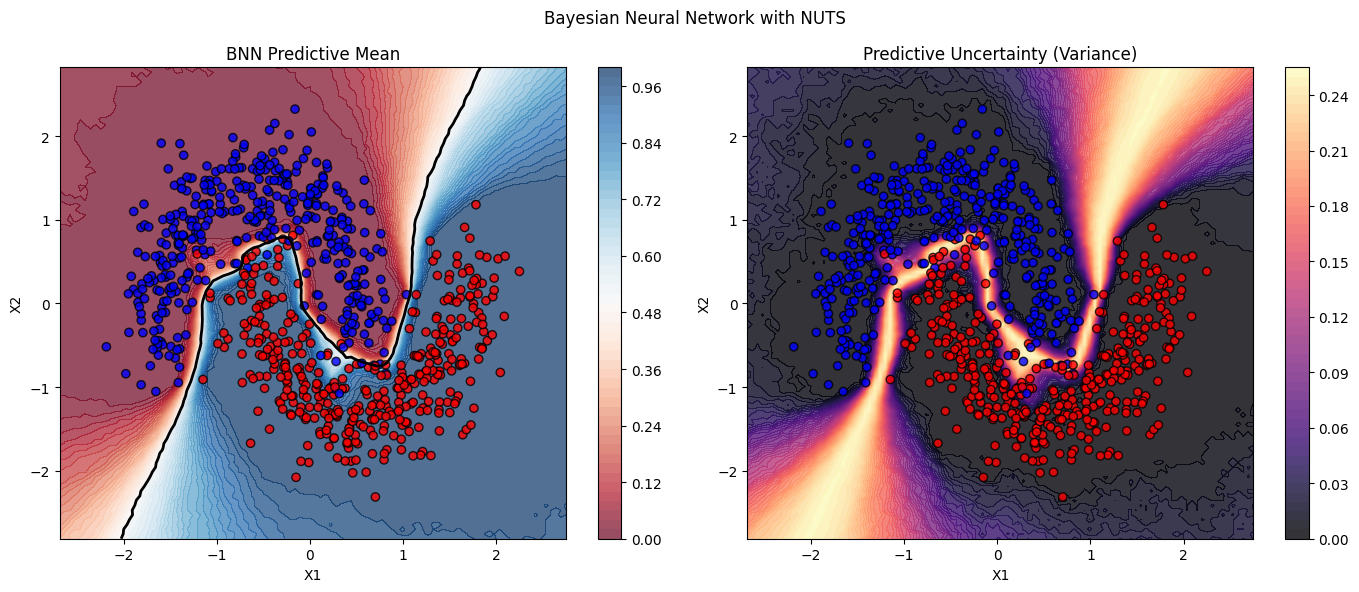

In [16]:
plot_bnn_with_uncertainty(predictive, X_train, y_train)

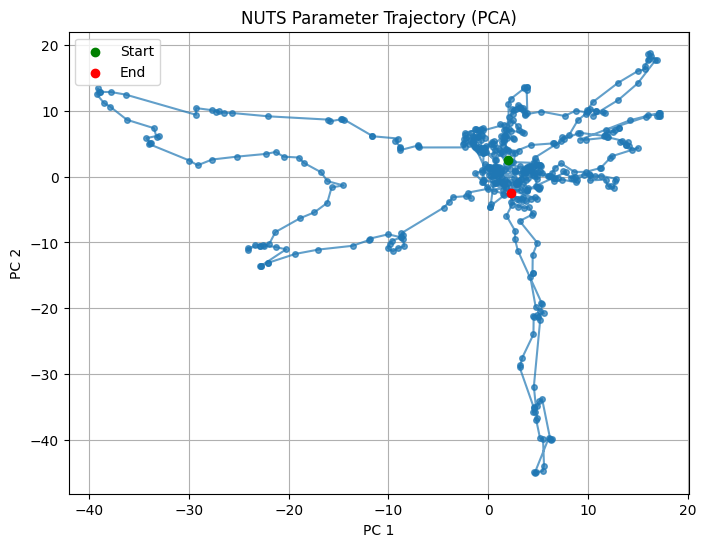

In [17]:
from sklearn.decomposition import PCA

def visualize_nuts_samples(samples):
    """
    Visualizes how parameter samples evolve during NUTS sampling using PCA.

    Args:
        samples (Tensor or dict): If Tensor, shape [num_samples, param_dim].
                                 If dict (from Pyro), flatten and concatenate params.
    """
    # If samples is a dict of tensors (common Pyro output), flatten and concatenate
    if isinstance(samples, dict):
        # Assume each key corresponds to a parameter tensor with shape [num_samples, ...]
        flat_samples = []
        for key, vals in samples.items():
            vals = vals.detach().cpu()
            vals = vals.view(vals.size(0), -1)  # flatten each param tensor per sample
            flat_samples.append(vals)
        samples = torch.cat(flat_samples, dim=1)
    elif isinstance(samples, torch.Tensor):
        if samples.dim() > 2:
            samples = samples.view(samples.size(0), -1)
    else:
        raise ValueError("samples must be a Tensor or dict of Tensors")

    samples_np = samples.cpu().numpy()

    # Apply PCA to reduce to 2D
    pca = PCA(n_components=2)
    reduced = pca.fit_transform(samples_np)

    # Plot trajectory
    plt.figure(figsize=(8, 6))
    plt.plot(reduced[:, 0], reduced[:, 1], '-o', markersize=4, alpha=0.7)
    plt.scatter(reduced[0, 0], reduced[0, 1], c='green', label='Start', zorder=5)
    plt.scatter(reduced[-1, 0], reduced[-1, 1], c='red', label='End', zorder=5)
    plt.title("NUTS Parameter Trajectory (PCA)")
    plt.xlabel("PC 1")
    plt.ylabel("PC 2")
    plt.legend()
    plt.grid(True)
    plt.show()

visualize_nuts_samples(mcmc.get_samples())

# ***Best Regards.***